# SWIR Processed-Box Analysis: Impact-Level Bruising Dynamics

This notebook uses the project train+validation SWIR split H5 files in `data/splits/train` and `data/splits/val`.

Analysis rule:
- `t0` is baseline-only: all `sound*` and `bruised*` boxes at `t0` are treated as sound tissue
- damaged-vs-sound comparisons are run only for `t1`, `t2`, and `t3`
- bruised boxes from `t1`-`t3` are reduced to a centered `20x20` patch before analysis, matching the original notebook

Impact groups:
- low impact: `280`, `281`, `290`, `291`
- medium impact: `282`, `292`, `283`, `293`
- high impact: `284`, `285`, `294`, `295`

Additional condition groups:
- warm condition: complete train+validation warm-condition samples
- cold condition: complete train+validation cold-condition samples
- whole sample: all complete train+validation samples

Wavelength values are mapped with `/home/emahan/sysops/HIPPA/bruising/references/swir_hippa_wl_calib_rounded.npy`, following `/home/emahan/sysops/HIPPA/hanif/band_wavelength_mapping.ipynb`.


In [37]:
from pathlib import Path
import math
import re
import gc

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from tqdm.auto import tqdm

PROJECT_ROOT = Path('/home/emahan/sysops/HIPPA/hanif/bruising_detection')
SPLIT_DIRS = [PROJECT_ROOT / 'data' / 'splits' / 'train', PROJECT_ROOT / 'data' / 'splits' / 'val']
SWIR_WL_CALIB_PATH = Path('/home/emahan/sysops/HIPPA/bruising/references/swir_hippa_wl_calib_rounded.npy')

TIMEPOINTS = ('t0', 't1', 't2', 't3')
DAMAGED_TIMEPOINTS = tuple(timepoint for timepoint in TIMEPOINTS if timepoint != 't0')
PLOT_TIMEPOINTS = DAMAGED_TIMEPOINTS
SOUND_PLOT_TIMEPOINTS = TIMEPOINTS
BRUISED_PLOT_TIMEPOINTS = DAMAGED_TIMEPOINTS
BASELINE_ONLY_TIMEPOINTS = ('t0',)
SENSOR_PREFIX = 'SWIR'
TOP_K = 10

FIGURE_DIR = PROJECT_ROOT / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, name: str):
    fig.savefig(FIGURE_DIR / f'{name}.png', dpi=200, bbox_inches='tight')


CODE_RE = re.compile(r'^MICROTEC_(\d+)_processed_boxes\.h5$')

pd.set_option('display.max_colwidth', 160)
plt.rcParams['figure.figsize'] = (12, 4)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
IMPACT_COLORS = {'baseline': '#2f3a4a', 't0': '#2f3a4a', 't1': '#d95f02', 't2': '#7570b3', 't3': '#1b9e77', 'low_impact': '#3b82f6', 'medium_impact': '#d8a03d', 'high_impact': '#ef4444'}

GROUP_DISPLAY_NAMES = {
    'low_impact': 'Low Impact',
    'medium_impact': 'Medium Impact',
    'high_impact': 'High Impact',
    'warm_condition': 'Warm Condition',
    'cold_condition': 'Cold Condition',
    'all_train_val_samples': 'All Train+Validation Samples',
}


def display_group_name(group_name: str) -> str:
    return GROUP_DISPLAY_NAMES.get(group_name, group_name.replace('_', ' ').title())



## Train, Validation, and Test Split Summary

This descriptive block summarizes the saved split files before the train+validation-only EDA sections below. It counts samples in train, validation, and test, plus warm/cold condition and low/medium/high impact membership.


In [38]:
SPLIT_SUMMARY_DIRS = {
    'train': PROJECT_ROOT / 'data' / 'splits' / 'train',
    'validation': PROJECT_ROOT / 'data' / 'splits' / 'val',
    'test': PROJECT_ROOT / 'data' / 'splits' / 'test',
}

SUMMARY_WARM_PREFIXES = ('28',)
SUMMARY_COLD_PREFIXES = ('29',)
SUMMARY_LOW_IMPACT_PREFIXES = ('280', '281', '290', '291')
SUMMARY_MEDIUM_IMPACT_PREFIXES = ('282', '292', '283', '293')
SUMMARY_HIGH_IMPACT_PREFIXES = ('284', '285', '294', '295')


def split_sample_codes(split_dir: Path) -> list[str]:
    codes = []
    for path in sorted(split_dir.glob('MICROTEC_*_processed_boxes.h5')):
        match = CODE_RE.match(path.name)
        if match:
            codes.append(match.group(1))
    return codes


def count_prefixes(codes: list[str], prefixes: tuple[str, ...]) -> int:
    return sum(any(code.startswith(prefix) for prefix in prefixes) for code in codes)


split_codes = {split: split_sample_codes(split_dir) for split, split_dir in SPLIT_SUMMARY_DIRS.items()}

split_summary_rows = []
for split, codes in split_codes.items():
    split_summary_rows.append({
        'split': split,
        'apples': len(codes),
        'warm_condition': count_prefixes(codes, SUMMARY_WARM_PREFIXES),
        'cold_condition': count_prefixes(codes, SUMMARY_COLD_PREFIXES),
        'low_impact': count_prefixes(codes, SUMMARY_LOW_IMPACT_PREFIXES),
        'medium_impact': count_prefixes(codes, SUMMARY_MEDIUM_IMPACT_PREFIXES),
        'high_impact': count_prefixes(codes, SUMMARY_HIGH_IMPACT_PREFIXES),
        'samples': len(codes) * 4,
        'warm_condition_samples': count_prefixes(codes, SUMMARY_WARM_PREFIXES) * 4,
        'cold_condition_samples': count_prefixes(codes, SUMMARY_COLD_PREFIXES) * 4,
        'low_impact_samples': count_prefixes(codes, SUMMARY_LOW_IMPACT_PREFIXES) * 4,
        'medium_impact_samples': count_prefixes(codes, SUMMARY_MEDIUM_IMPACT_PREFIXES) * 4,
        'high_impact_samples': count_prefixes(codes, SUMMARY_HIGH_IMPACT_PREFIXES) * 4,
    })

all_split_codes = [code for codes in split_codes.values() for code in codes]
split_summary_rows.append({
    'split': 'total',
    'apples': len(all_split_codes),
    'warm_condition': count_prefixes(all_split_codes, SUMMARY_WARM_PREFIXES),
    'cold_condition': count_prefixes(all_split_codes, SUMMARY_COLD_PREFIXES),
    'low_impact': count_prefixes(all_split_codes, SUMMARY_LOW_IMPACT_PREFIXES),
    'medium_impact': count_prefixes(all_split_codes, SUMMARY_MEDIUM_IMPACT_PREFIXES),
    'high_impact': count_prefixes(all_split_codes, SUMMARY_HIGH_IMPACT_PREFIXES),
    'samples': len(all_split_codes) * 4,
    'warm_condition_samples': count_prefixes(all_split_codes, SUMMARY_WARM_PREFIXES) * 4,
    'cold_condition_samples': count_prefixes(all_split_codes, SUMMARY_COLD_PREFIXES) * 4,
    'low_impact_samples': count_prefixes(all_split_codes, SUMMARY_LOW_IMPACT_PREFIXES) * 4,
    'medium_impact_samples': count_prefixes(all_split_codes, SUMMARY_MEDIUM_IMPACT_PREFIXES) * 4,
    'high_impact_samples': count_prefixes(all_split_codes, SUMMARY_HIGH_IMPACT_PREFIXES) * 4,
})

split_summary_df = pd.DataFrame(split_summary_rows)

display(Markdown('**Sample counts by split, condition, and impact level**'))
display(split_summary_df)


**Sample counts by split, condition, and impact level**

,split,apples,warm_condition,cold_condition,low_impact,medium_impact,high_impact,samples,warm_condition_samples,cold_condition_samples,low_impact_samples,medium_impact_samples,high_impact_samples
0,train,94,46,48,30,32,32,376,184,192,120,128,128
1,validation,12,6,6,4,4,4,48,24,24,16,16,16
2,test,12,6,6,4,4,4,48,24,24,16,16,16
3,total,118,58,60,38,40,40,472,232,240,152,160,160


In [39]:
def extract_code(path: Path) -> str | None:
    match = CODE_RE.match(path.name)
    return match.group(1) if match else None


H5_PATH_BY_CODE = {}
for split_dir in SPLIT_DIRS:
    for path in sorted(split_dir.glob('MICROTEC_*_processed_boxes.h5')):
        code = extract_code(path)
        if code is not None:
            H5_PATH_BY_CODE[code] = path


def processed_h5_path(code: str) -> Path:
    return H5_PATH_BY_CODE[code]


def _decode_attr(value):
    if isinstance(value, bytes):
        return value.decode('utf-8')
    return value


def dataset_roi_type(name: str, dataset: h5py.Dataset) -> str:
    attr = _decode_attr(dataset.attrs.get('roi_type', ''))
    if attr:
        return str(attr)
    lname = name.lower()
    if lname.startswith('sound'):
        return 'sound'
    if lname.startswith('bruised'):
        return 'bruised'
    return 'unknown'


def inventory_for_code(code: str) -> tuple[pd.DataFrame, bool]:
    path = processed_h5_path(code)
    rows = []
    with h5py.File(path, 'r') as handle:
        for timepoint in TIMEPOINTS:
            group_name = f'{SENSOR_PREFIX}_{timepoint}'
            group_exists = group_name in handle
            sound_boxes = 0
            bruised_boxes = 0
            n_bands = None
            source_file = ''
            if group_exists:
                group = handle[group_name]
                source_file = _decode_attr(group.attrs.get('source_file', ''))
                for ds_name, ds in group.items():
                    if not isinstance(ds, h5py.Dataset):
                        continue
                    roi_type = dataset_roi_type(ds_name, ds)
                    if timepoint in BASELINE_ONLY_TIMEPOINTS and roi_type in {'sound', 'bruised'}:
                        sound_boxes += 1
                    elif roi_type == 'sound':
                        sound_boxes += 1
                    elif roi_type == 'bruised':
                        bruised_boxes += 1
                    n_bands = int(ds.shape[-1])
            rows.append({
                'sample_code': code,
                'timepoint': timepoint,
                'group_exists': group_exists,
                'sound_boxes': sound_boxes,
                'bruised_boxes': bruised_boxes,
                'n_bands': n_bands,
                'source_file': source_file,
            })
    df = pd.DataFrame(rows)
    is_complete = bool(
        df['group_exists'].all()
        and (df['sound_boxes'] > 0).all()
        and (df.loc[df['timepoint'].isin(DAMAGED_TIMEPOINTS), 'bruised_boxes'] > 0).all()
    )
    return df, is_complete


inventory_rows = []
complete_codes = []
incomplete_codes = []

for path in sorted(H5_PATH_BY_CODE.values()):
    code = extract_code(path)
    if code is None:
        continue
    code_df, is_complete = inventory_for_code(code)
    inventory_rows.extend(code_df.to_dict('records'))
    if is_complete:
        complete_codes.append(code)
    else:
        incomplete_codes.append(code)

inventory_df = pd.DataFrame(inventory_rows).sort_values(['sample_code', 'timepoint']).reset_index(drop=True)
inventory_summary_df = (
    inventory_df
    .groupby('sample_code', as_index=False)
    .agg(
        timepoints_found=('group_exists', 'sum'),
        min_sound_boxes=('sound_boxes', 'min'),
        min_damaged_timepoint_bruised_boxes=(
            'bruised_boxes',
            lambda values: values[inventory_df.loc[values.index, 'timepoint'].isin(DAMAGED_TIMEPOINTS)].min(),
        ),
        bands=('n_bands', 'max'),
    )
    .sort_values('sample_code')
    .reset_index(drop=True)
)

print(f'Processed H5 files found: {inventory_summary_df.shape[0]}')
print(f'Complete samples with SWIR_t0 baseline boxes plus SWIR_t1, SWIR_t2, SWIR_t3 sound and bruised boxes: {len(complete_codes)}')
print(f'Incomplete samples: {len(incomplete_codes)}')
if incomplete_codes:
    print('Incomplete codes:', incomplete_codes)

display(Markdown('**Per-sample inventory summary**'))
display(inventory_summary_df)


Processed H5 files found: 106
Complete samples with SWIR_t0 baseline boxes plus SWIR_t1, SWIR_t2, SWIR_t3 sound and bruised boxes: 106
Incomplete samples: 0


**Per-sample inventory summary**

,sample_code,timepoints_found,min_sound_boxes,min_damaged_timepoint_bruised_boxes,bands
0,28002,4,4,4,220
1,28003,4,4,4,220
2,28004,4,4,4,220
3,28005,4,4,4,220
4,28006,4,4,4,220
...,...,...,...,...,...
101,29504,4,4,4,220
102,29505,4,4,4,220
103,29506,4,4,4,220
104,29508,4,4,4,220


In [40]:
LOW_IMPACT_PREFIXES = ('280', '281', '290', '291')
MEDIUM_IMPACT_PREFIXES = ('282', '292', '283', '293')
HIGH_IMPACT_PREFIXES = ('284', '285', '294', '295')
IMPACT_GROUPS = {
    'low_impact': LOW_IMPACT_PREFIXES,
    'medium_impact': MEDIUM_IMPACT_PREFIXES,
    'high_impact': HIGH_IMPACT_PREFIXES,
}


def codes_for_prefixes(prefixes) -> list[str]:
    return sorted(code for code in complete_codes if any(code.startswith(prefix) for prefix in prefixes))


REQUESTED_GROUPS = {name: codes_for_prefixes(prefixes) for name, prefixes in IMPACT_GROUPS.items()}

missing_groups = [name for name, codes in REQUESTED_GROUPS.items() if not codes]
if missing_groups:
    raise ValueError(f'No complete samples found for: {missing_groups}')

group_summary_rows = []
group_timepoint_rows = []
for name, prefixes in IMPACT_GROUPS.items():
    codes = REQUESTED_GROUPS[name]
    group_inventory = inventory_df[inventory_df['sample_code'].isin(codes)].copy()
    group_summary_rows.append({
        'impact_group': name,
        'n_samples': len(codes),
    })
    for timepoint in TIMEPOINTS:
        subset = group_inventory[group_inventory['timepoint'] == timepoint]
        group_timepoint_rows.append({
            'impact_group': name,
            'timepoint': timepoint,
            'samples': subset['sample_code'].nunique(),
            'sound_boxes': int(subset['sound_boxes'].sum()),
            'bruised_boxes': int(subset['bruised_boxes'].sum()) if timepoint in DAMAGED_TIMEPOINTS else 0,
        })

group_summary_df = pd.DataFrame(group_summary_rows)
group_timepoint_df = pd.DataFrame(group_timepoint_rows)

display(Markdown('**Impact group summary**'))
display(group_summary_df)

display(Markdown('**Impact group x timepoint box counts**'))
display(group_timepoint_df)


**Impact group summary**

,impact_group,n_samples
0,low_impact,34
1,medium_impact,36
2,high_impact,36


**Impact group x timepoint box counts**

,impact_group,timepoint,samples,sound_boxes,bruised_boxes
0,low_impact,t0,34,272,0
1,low_impact,t1,34,136,136
2,low_impact,t2,34,136,136
3,low_impact,t3,34,136,136
4,medium_impact,t0,36,288,0
5,medium_impact,t1,36,144,144
6,medium_impact,t2,36,144,144
7,medium_impact,t3,36,144,144
8,high_impact,t0,36,288,0
9,high_impact,t1,36,144,144


In [41]:
def _get_wavelength_axis(n_bands: int) -> np.ndarray:
    wavelengths = np.load(SWIR_WL_CALIB_PATH).astype(np.float32)
    if wavelengths.shape[0] == n_bands:
        return wavelengths
    if wavelengths.shape[0] > n_bands:
        return wavelengths[:n_bands]
    raise ValueError(
        f'SWIR wavelength mapping has {wavelengths.shape[0]} bands, but the data has {n_bands} bands.'
    )


def _sorted_dataset_names(group: h5py.Group, roi_type: str) -> list[str]:
    names = []
    for ds_name, ds in group.items():
        if not isinstance(ds, h5py.Dataset):
            continue
        if dataset_roi_type(ds_name, ds) == roi_type:
            names.append(ds_name)

    def sort_key(name: str):
        match = re.search(r'(\d+)$', name)
        return (int(match.group(1)) if match else 0, name)

    return sorted(names, key=sort_key)


def center_crop_cube(cube: np.ndarray, crop_h: int, crop_w: int) -> np.ndarray:
    array = np.asarray(cube)
    if array.ndim != 3:
        raise ValueError(f'Expected a 3D cube, got shape={array.shape}')

    height, width, _ = array.shape
    if crop_h > height or crop_w > width:
        raise ValueError(
            f'Center crop {crop_h}x{crop_w} is larger than cube shape {array.shape}'
        )

    y0 = (height - crop_h) // 2
    x0 = (width - crop_w) // 2
    return array[y0:y0 + crop_h, x0:x0 + crop_w, :]


def load_box_cubes(code: str, timepoint: str, roi_type: str) -> list[np.ndarray]:
    if timepoint in BASELINE_ONLY_TIMEPOINTS and roi_type == 'bruised':
        raise ValueError(f'{timepoint} is baseline-only; bruised cubes are not loaded for analysis')

    path = processed_h5_path(code)
    group_name = f'{SENSOR_PREFIX}_{timepoint}'
    with h5py.File(path, 'r') as handle:
        if group_name not in handle:
            raise KeyError(f'{group_name} is missing in {path.name}')
        group = handle[group_name]
        if timepoint in BASELINE_ONLY_TIMEPOINTS and roi_type == 'sound':
            names = sorted(
                _sorted_dataset_names(group, 'sound') + _sorted_dataset_names(group, 'bruised')
            )
        else:
            names = _sorted_dataset_names(group, roi_type)
        cubes = [group[name][()] for name in names]

    if not cubes:
        raise ValueError(f'No {roi_type} cubes found for {code} at {timepoint}')

    if roi_type == 'bruised':
        cubes = [center_crop_cube(cube, crop_h=20, crop_w=20) for cube in cubes]

    return cubes


def cube_band_values(cube: np.ndarray) -> np.ndarray:
    array = np.asarray(cube, dtype=np.float32)
    if array.ndim != 3:
        raise ValueError(f'Expected a 3D cube, got shape={array.shape}')
    return array.reshape(-1, array.shape[-1])


def compute_group_average_spectra(sample_codes, timepoints=TIMEPOINTS):
    sound_lists = {t: [] for t in timepoints}
    bruised_lists = {t: [] for t in timepoints}

    sound_sum = {t: None for t in timepoints}
    bruised_sum = {t: None for t in timepoints}
    sound_pixels = {t: 0 for t in timepoints}
    bruised_pixels = {t: 0 for t in timepoints}

    iterator = tqdm(sample_codes, desc='processed-box spectra', unit='sample')
    for code in iterator:
        for timepoint in timepoints:
            for cube in load_box_cubes(code, timepoint, 'sound'):
                values = cube_band_values(cube)
                sound_lists[timepoint].append(values.mean(axis=0))
                total = values.sum(axis=0, dtype=np.float64)
                sound_sum[timepoint] = total if sound_sum[timepoint] is None else (sound_sum[timepoint] + total)
                sound_pixels[timepoint] += int(values.shape[0])

            if timepoint in DAMAGED_TIMEPOINTS:
                for cube in load_box_cubes(code, timepoint, 'bruised'):
                    values = cube_band_values(cube)
                    bruised_lists[timepoint].append(values.mean(axis=0))
                    total = values.sum(axis=0, dtype=np.float64)
                    bruised_sum[timepoint] = total if bruised_sum[timepoint] is None else (bruised_sum[timepoint] + total)
                    bruised_pixels[timepoint] += int(values.shape[0])

    sound_stack = {t: np.stack(sound_lists[t], axis=0) for t in timepoints}
    bruised_stack = {t: np.stack(bruised_lists[t], axis=0) for t in timepoints if t in DAMAGED_TIMEPOINTS}

    n_bands = next(iter(sound_stack.values())).shape[1]
    bands = _get_wavelength_axis(n_bands)

    return {
        'codes': list(sample_codes),
        'timepoints': list(timepoints),
        'bands': bands,
        'sound_mean': {
            t: (sound_sum[t] / sound_pixels[t]).astype(np.float32)
            for t in timepoints
        },
        'bruised_mean': {
            t: (bruised_sum[t] / bruised_pixels[t]).astype(np.float32)
            for t in timepoints if t in DAMAGED_TIMEPOINTS
        },
        'sound_stack': sound_stack,
        'bruised_stack': bruised_stack,
        'sound_box_counts': {t: len(sound_lists[t]) for t in timepoints},
        'bruised_box_counts': {t: len(bruised_lists[t]) for t in timepoints},
        'sound_pixel_counts': sound_pixels,
        'bruised_pixel_counts': bruised_pixels,
    }


Example bruised box: timepoint=t3, dataset=bruised1, full_shape=(160, 160, 220), center_crop_shape=(20, 20, 220), center_crop_xy=(70, 70)


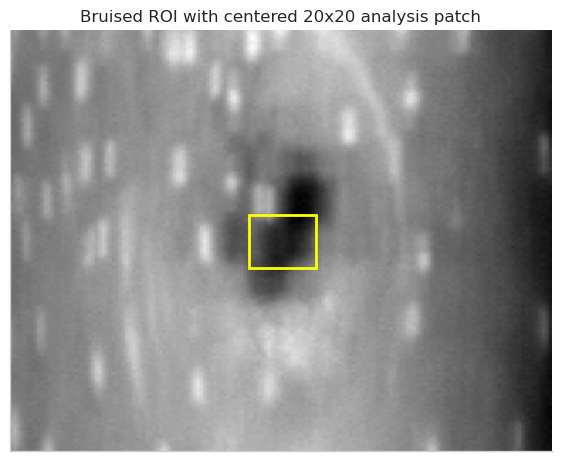

In [42]:
from matplotlib.patches import Rectangle

EXAMPLE_SAMPLE_CODE = REQUESTED_GROUPS['high_impact'][5]
EXAMPLE_TIMEPOINT = 't3'
EXAMPLE_BRUISED_DATASET = 'bruised1'
EXAMPLE_BAND = 99

example_path = processed_h5_path(EXAMPLE_SAMPLE_CODE)
example_group_name = f'{SENSOR_PREFIX}_{EXAMPLE_TIMEPOINT}'

with h5py.File(example_path, 'r') as handle:
    example_cube = handle[example_group_name][EXAMPLE_BRUISED_DATASET][()]

example_center_crop = center_crop_cube(example_cube, crop_h=20, crop_w=20)
band_index = min(EXAMPLE_BAND, example_cube.shape[2] - 1)

height, width, _ = example_cube.shape
crop_h, crop_w = example_center_crop.shape[:2]
y0 = (height - crop_h) // 2
x0 = (width - crop_w) // 2

print(
    f'Example bruised box: timepoint={EXAMPLE_TIMEPOINT}, dataset={EXAMPLE_BRUISED_DATASET}, '
    f'full_shape={example_cube.shape}, center_crop_shape={example_center_crop.shape}, '
    f'center_crop_xy=({x0}, {y0})'
)

fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)

ax.imshow(example_cube[:, :, band_index], cmap='gray', aspect='auto')
ax.add_patch(Rectangle((x0, y0), crop_w, crop_h, fill=False, edgecolor='yellow', linewidth=2))
ax.set_title(f'Bruised ROI with centered 20x20 analysis patch')
ax.set_xticks([])
ax.set_yticks([])

save_figure(fig, f'bruised_roi_centered_20x20_overlay_{EXAMPLE_SAMPLE_CODE}_{EXAMPLE_TIMEPOINT}')
plt.show()


In [43]:
def impact_baseline(group_data, timepoint):
    return group_data['sound_mean'][timepoint]


def impact_curve(group_data, timepoint):
    return group_data['bruised_mean'][timepoint]


def plot_group_top_distinctive_bands(group_name, group_data, top_k=10):
    bands = group_data['bands']
    for timepoint in PLOT_TIMEPOINTS:
        if timepoint not in group_data['timepoints']:
            continue
        score = np.abs(impact_curve(group_data, timepoint) - impact_baseline(group_data, timepoint))
        idx = np.argsort(score)[::-1][:top_k]
        print(f'[{display_group_name(group_name)}] Top {top_k} changing wavelengths: sound {timepoint} vs bruised {timepoint}')
        for i, band_index in enumerate(idx, 1):
            print(f'{i}. wavelength={bands[band_index]:.1f} nm: |Δ|={score[band_index]:.6f}')

        fig, ax = plt.subplots(figsize=(12, 4.5))
        ax.plot(bands, score, color=IMPACT_COLORS.get(timepoint, 'crimson'), linewidth=2.2, label=f'|bruised {timepoint} - sound {timepoint}|')
        ax.scatter(bands[idx], score[idx], color='black', s=28, zorder=3, label='top wavelengths')
        for band_index in idx[:5]:
            ax.text(float(bands[band_index]), float(score[band_index]), f' {bands[band_index]:.1f}', fontsize=9)
        ax.set_title(f'{display_group_name(group_name)} | strongest same-timepoint wavelength changes', fontsize=14, weight='bold')
        ax.set_xlabel('Wavelength (nm)')
        ax.set_ylabel('Absolute reflectance change')
        ax.legend(frameon=False)
        plt.tight_layout()
        save_figure(fig, f'{group_name}_{timepoint}_top_distinctive_wavelengths')
        plt.show()
        plt.close(fig)


def plot_group_sound_vs_bruised_timepoints(group_name, group_data):
    bands = group_data['bands']
    fig, ax = plt.subplots(figsize=(12, 5))
    for timepoint in SOUND_PLOT_TIMEPOINTS:
        if timepoint in group_data['timepoints']:
            label = f'baseline sound {timepoint}' if timepoint in BASELINE_ONLY_TIMEPOINTS else f'sound {timepoint}'
            ax.plot(bands, impact_baseline(group_data, timepoint), color=IMPACT_COLORS.get(timepoint), linewidth=2.0, linestyle='--', label=label)
            if timepoint in BRUISED_PLOT_TIMEPOINTS:
                ax.plot(bands, impact_curve(group_data, timepoint), color=IMPACT_COLORS.get(timepoint), linewidth=2.2, label=f'bruised {timepoint}')
    ax.set_title(f'{display_group_name(group_name)} | sound vs bruised spectra by timepoint', fontsize=15, weight='bold')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Mean reflectance')
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    save_figure(fig, f'{group_name}_sound_vs_bruised_timepoints')
    plt.show()
    plt.close(fig)


def plot_group_same_timepoint_change(group_name, group_data):
    bands = group_data['bands']
    fig, axs = plt.subplots(1, 2, figsize=(15, 4.8), constrained_layout=True)
    for timepoint in SOUND_PLOT_TIMEPOINTS:
        if timepoint in group_data['timepoints']:
            label = f'baseline sound {timepoint}' if timepoint in BASELINE_ONLY_TIMEPOINTS else f'sound {timepoint}'
            axs[0].plot(bands, impact_baseline(group_data, timepoint), color=IMPACT_COLORS[timepoint], linewidth=2.0, linestyle='--', label=label)
            if timepoint in BRUISED_PLOT_TIMEPOINTS:
                axs[0].plot(bands, impact_curve(group_data, timepoint), color=IMPACT_COLORS[timepoint], linewidth=2.2, label=f'bruised {timepoint}')
    axs[0].set_title('Raw mean spectra', fontsize=13, weight='bold')
    axs[0].set_xlabel('Wavelength (nm)')
    axs[0].set_ylabel('Mean reflectance')
    axs[0].legend(frameon=False, ncol=2)

    for timepoint in PLOT_TIMEPOINTS:
        if timepoint not in group_data['timepoints']:
            continue
        delta = impact_curve(group_data, timepoint) - impact_baseline(group_data, timepoint)
        bmax = int(np.argmax(np.abs(delta)))
        axs[1].plot(bands, delta, color=IMPACT_COLORS[timepoint], linewidth=2.2, label=f'bruised {timepoint} - sound {timepoint}')
        axs[1].scatter([bands[bmax]], [delta[bmax]], color='black', s=25, zorder=3)
    axs[1].axhline(0.0, color='gray', linestyle=':', linewidth=1.2)
    axs[1].set_title('Same-timepoint change', fontsize=13, weight='bold')
    axs[1].set_xlabel('Wavelength (nm)')
    axs[1].set_ylabel('Reflectance change')
    axs[1].legend(frameon=False)
    fig.suptitle(f'{display_group_name(group_name)} | bruising dynamics', fontsize=16, weight='bold')
    save_figure(fig, f'{group_name}_same_timepoint_change')
    plt.show()
    plt.close(fig)


def plot_group_temporal_evolution(group_name, group_data):
    sound_labels = [tp for tp in SOUND_PLOT_TIMEPOINTS if tp in group_data['timepoints']]
    sound_values = [impact_baseline(group_data, tp).mean() for tp in sound_labels]
    bruised_labels = [tp for tp in BRUISED_PLOT_TIMEPOINTS if tp in group_data['timepoints']]
    bruised_values = [impact_curve(group_data, tp).mean() for tp in bruised_labels]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(sound_labels, sound_values, marker='o', linewidth=2.3, color='#2f3a4a', label='sound')
    ax.plot(bruised_labels, bruised_values, marker='o', linewidth=2.3, color='#ef4444', label='bruised')
    ax.set_title(f'{display_group_name(group_name)} | mean spectral intensity trajectory', fontsize=14, weight='bold')
    ax.set_ylabel('Mean reflectance across wavelengths')
    ax.legend(frameon=False)
    plt.tight_layout()
    save_figure(fig, f'{group_name}_mean_spectral_intensity_trajectory')
    plt.show()
    plt.close(fig)


def plot_group_variance(group_name, group_data):
    bands = group_data['bands']
    fig, ax = plt.subplots(figsize=(12, 5))
    for timepoint in SOUND_PLOT_TIMEPOINTS:
        if timepoint not in group_data['timepoints']:
            continue
        sound_label = f'baseline sound {timepoint}' if timepoint in BASELINE_ONLY_TIMEPOINTS else f'sound {timepoint}'
        plot_items = [(sound_label, group_data['sound_stack'][timepoint], '--')]
        if timepoint in BRUISED_PLOT_TIMEPOINTS:
            plot_items.append((f'bruised {timepoint}', group_data['bruised_stack'][timepoint], '-'))
        for label, stack, style in plot_items:
            mean = stack.mean(axis=0)
            std = stack.std(axis=0)
            color = IMPACT_COLORS[timepoint]
            ax.plot(bands, mean, color=color, linestyle=style, linewidth=2.0, label=label)
            ax.fill_between(bands, mean - std, mean + std, color=color, alpha=0.10)
    ax.set_title(f'{display_group_name(group_name)} | spectral variance (shade = +/-1 std)', fontsize=14, weight='bold')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Mean reflectance')
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    save_figure(fig, f'{group_name}_spectral_variance')
    plt.show()
    plt.close(fig)


In [44]:
def top_distinctive_nonoverlap_bands_from_group_data(group_data, top_k=5, timepoints=PLOT_TIMEPOINTS):
    bands = group_data['bands']
    best_score = np.full(len(bands), -np.inf, dtype=float)
    best_timepoint = np.array([''] * len(bands), dtype=object)

    for timepoint in timepoints:
        if timepoint not in group_data['timepoints']:
            continue
        sound_stack = group_data['sound_stack'][timepoint]
        bruised_stack = group_data['bruised_stack'][timepoint]
        sound_mean, sound_std = sound_stack.mean(axis=0), sound_stack.std(axis=0)
        bruised_mean, bruised_std = bruised_stack.mean(axis=0), bruised_stack.std(axis=0)
        non_overlap = (sound_mean + sound_std < bruised_mean - bruised_std) | (bruised_mean + bruised_std < sound_mean - sound_std)
        score = np.where(non_overlap, np.abs(bruised_mean - sound_mean), -np.inf)
        improved = score > best_score
        best_score[improved] = score[improved]
        best_timepoint[improved] = timepoint

    valid_idx = np.where(np.isfinite(best_score))[0]
    if len(valid_idx) == 0:
        print('No wavelengths satisfy the non-overlap condition.')
        return {'bands': [], 'scores': [], 'timepoints': []}
    top_idx = valid_idx[np.argsort(best_score[valid_idx])[::-1]][:top_k]
    return {'bands': [int(b) for b in top_idx], 'scores': [float(best_score[b]) for b in top_idx], 'timepoints': [str(best_timepoint[b]) for b in top_idx]}


def boxplot_distinctive_bands(group_data, topk_result, group_name):
    if not topk_result['bands']:
        print(f'No distinctive wavelengths available for {group_name}.')
        return
    n_items = len(topk_result['bands'])
    ncols = min(3, n_items)
    nrows = math.ceil(n_items / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    bands = group_data['bands']
    for ax, band_index, timepoint, score in zip(axes, topk_result['bands'], topk_result['timepoints'], topk_result['scores']):
        sound_vals = group_data['sound_stack'][timepoint][:, band_index]
        bruised_vals = group_data['bruised_stack'][timepoint][:, band_index]
        ax.boxplot([sound_vals, bruised_vals], labels=[f'sound {timepoint}', f'bruised {timepoint}'], patch_artist=True)
        ax.set_title(f'{display_group_name(group_name)} | {bands[band_index]:.1f} nm\n{timepoint}, score={score:.4f}', fontsize=10, weight='bold')
        ax.set_ylabel('Mean center-crop reflectance')
        ax.grid(alpha=0.2)
    for ax in axes[n_items:]:
        ax.axis('off')
    fig.suptitle(f'Distinctive wavelength boxplots | {display_group_name(group_name)}', fontsize=14, weight='bold')
    save_figure(fig, f'{group_name}_distinctive_wavelength_boxplots')
    plt.show()
    plt.close(fig)


def summarize_group_inputs(group_name, group_data):
    print('ROI / pixel counts used per timepoint:')
    for timepoint in TIMEPOINTS:
        if timepoint in DAMAGED_TIMEPOINTS:
            print(f'  {timepoint}: sound_boxes={group_data["sound_box_counts"][timepoint]}, sound_pixels={group_data["sound_pixel_counts"][timepoint]}, bruised_boxes={group_data["bruised_box_counts"][timepoint]}, bruised_pixels={group_data["bruised_pixel_counts"][timepoint]}, n_samples={len(group_data["codes"])}')
        else:
            print(f'  {timepoint}: baseline_sound_boxes={group_data["sound_box_counts"][timepoint]}, baseline_sound_pixels={group_data["sound_pixel_counts"][timepoint]}, bruised_boxes=0, bruised_pixels=0, n_samples={len(group_data["codes"])}')


def run_full_group_analysis(group_name, sample_codes, top_k=TOP_K, show_boxplots=False, section_label='Analysis group'):
    print('\n' + '=' * 70)
    pretty_name = display_group_name(group_name)
    print(f'{section_label}: {pretty_name} | n={len(sample_codes)}')
    group_data = compute_group_average_spectra(sample_codes, timepoints=TIMEPOINTS)
    summarize_group_inputs(group_name, group_data)
    plot_group_top_distinctive_bands(group_name, group_data, top_k=top_k)
    plot_group_sound_vs_bruised_timepoints(group_name, group_data)
    plot_group_same_timepoint_change(group_name, group_data)
    plot_group_temporal_evolution(group_name, group_data)
    plot_group_variance(group_name, group_data)
    topk_result = top_distinctive_nonoverlap_bands_from_group_data(group_data, top_k=top_k)
    print(f'Non-overlap top wavelengths for {group_name}: {topk_result}')
    if show_boxplots:
        boxplot_distinctive_bands(group_data, topk_result, group_name)
    gc.collect()
    return {'group_data': group_data, 'topk_result': topk_result}



Impact group: Low Impact | n=34


processed-box spectra: 100%|██████████| 34/34 [00:45<00:00,  1.32s/sample]


ROI / pixel counts used per timepoint:
  t0: baseline_sound_boxes=272, baseline_sound_pixels=6963200, bruised_boxes=0, bruised_pixels=0, n_samples=34
  t1: sound_boxes=136, sound_pixels=3481600, bruised_boxes=136, bruised_pixels=54400, n_samples=34
  t2: sound_boxes=136, sound_pixels=3481600, bruised_boxes=136, bruised_pixels=54400, n_samples=34
  t3: sound_boxes=136, sound_pixels=3481600, bruised_boxes=136, bruised_pixels=54400, n_samples=34
[Low Impact] Top 10 changing wavelengths: sound t1 vs bruised t1
1. wavelength=1216.5 nm: |Δ|=10.109772
2. wavelength=1213.4 nm: |Δ|=10.076675
3. wavelength=1219.7 nm: |Δ|=10.074860
4. wavelength=1210.2 nm: |Δ|=10.040497
5. wavelength=1222.9 nm: |Δ|=10.037041
6. wavelength=1207.0 nm: |Δ|=10.009216
7. wavelength=1226.1 nm: |Δ|=10.002785
8. wavelength=1203.8 nm: |Δ|=10.001266
9. wavelength=1197.5 nm: |Δ|=9.990364
10. wavelength=1200.7 nm: |Δ|=9.971138


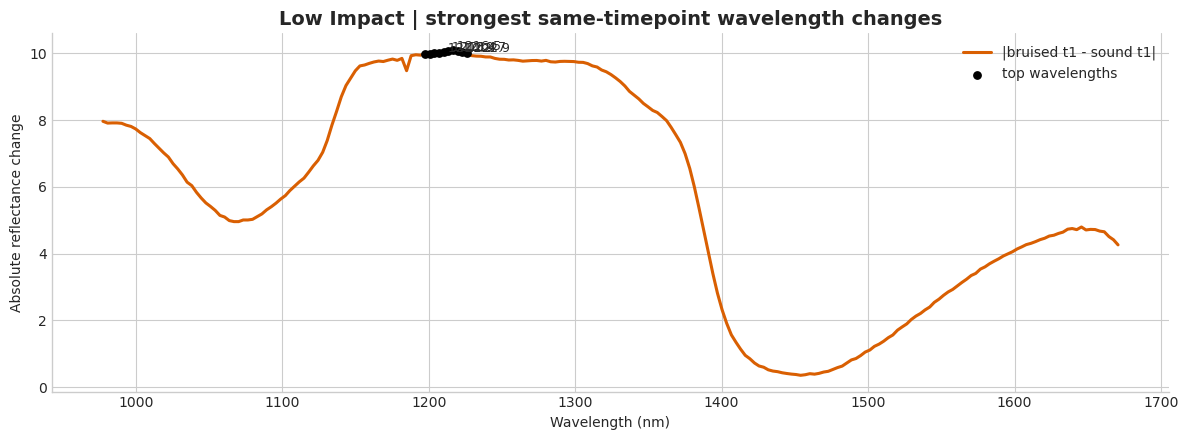

[Low Impact] Top 10 changing wavelengths: sound t2 vs bruised t2
1. wavelength=1375.0 nm: |Δ|=4.427444
2. wavelength=1378.2 nm: |Δ|=4.410332
3. wavelength=1371.8 nm: |Δ|=4.386101
4. wavelength=1381.3 nm: |Δ|=4.357372
5. wavelength=1368.7 nm: |Δ|=4.319542
6. wavelength=1365.5 nm: |Δ|=4.303551
7. wavelength=1362.4 nm: |Δ|=4.281151
8. wavelength=1384.5 nm: |Δ|=4.229496
9. wavelength=1359.2 nm: |Δ|=4.223358
10. wavelength=1356.0 nm: |Δ|=4.169884


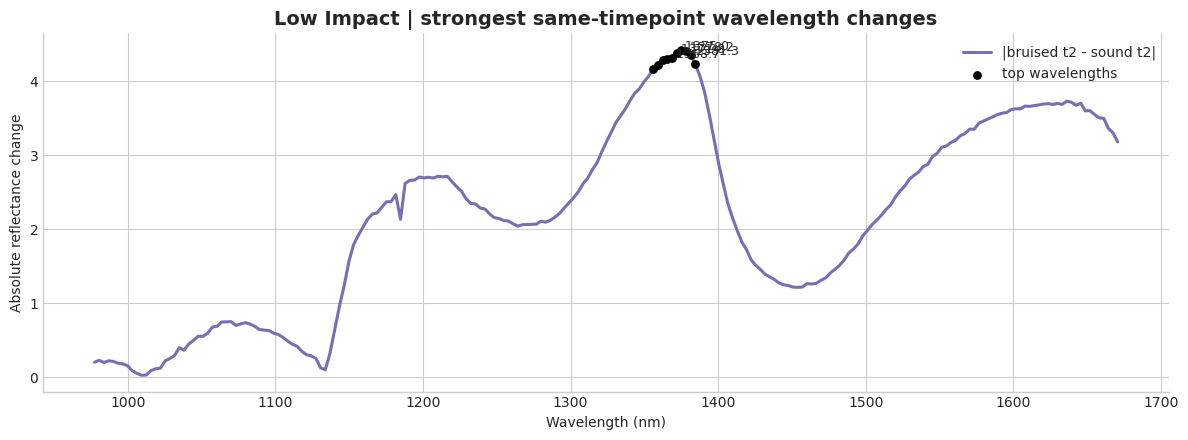

[Low Impact] Top 10 changing wavelengths: sound t3 vs bruised t3
1. wavelength=1286.4 nm: |Δ|=20.833176
2. wavelength=1283.2 nm: |Δ|=20.831184
3. wavelength=1289.5 nm: |Δ|=20.822449
4. wavelength=1264.2 nm: |Δ|=20.821472
5. wavelength=1273.7 nm: |Δ|=20.814102
6. wavelength=1267.3 nm: |Δ|=20.811737
7. wavelength=1276.9 nm: |Δ|=20.810005
8. wavelength=1270.5 nm: |Δ|=20.805328
9. wavelength=1261.0 nm: |Δ|=20.798798
10. wavelength=1292.7 nm: |Δ|=20.793633


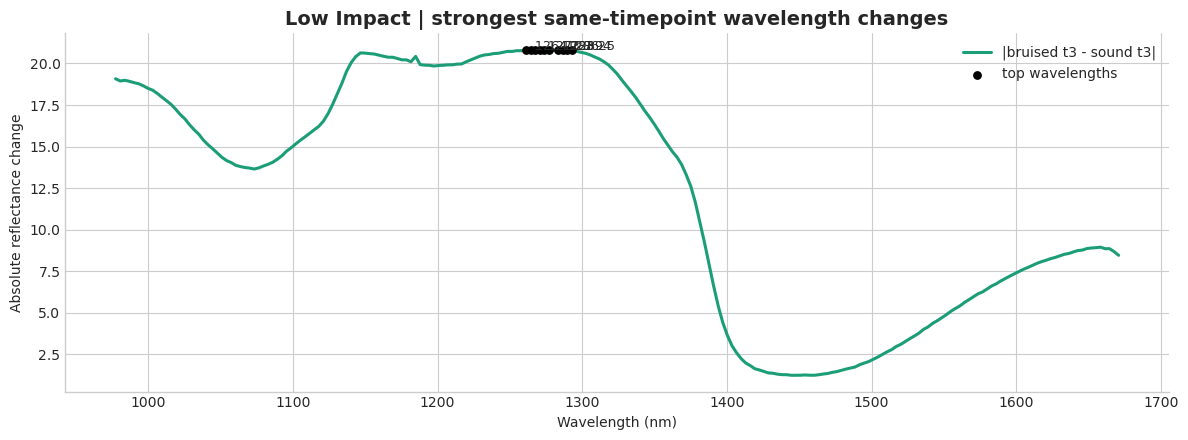

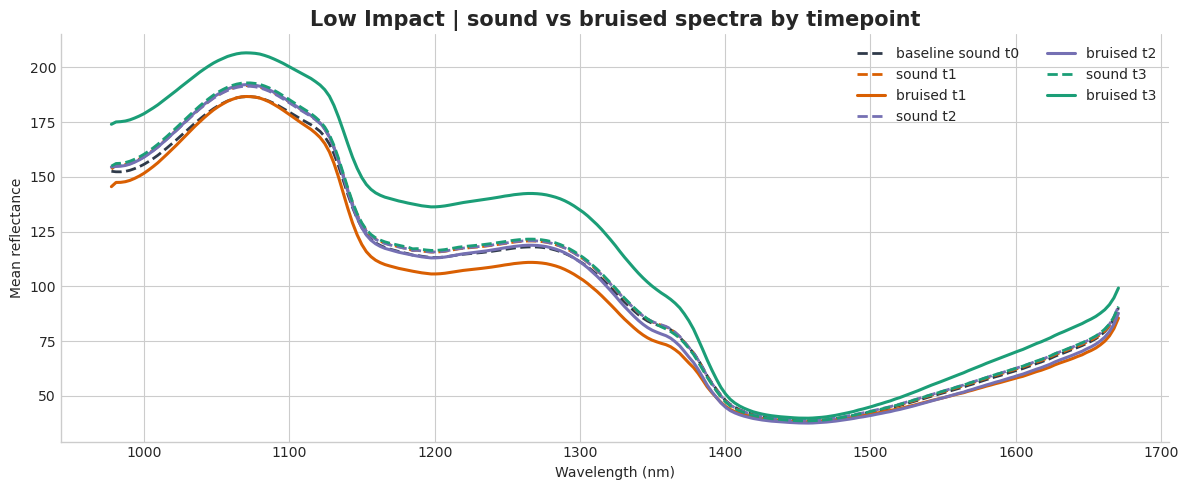

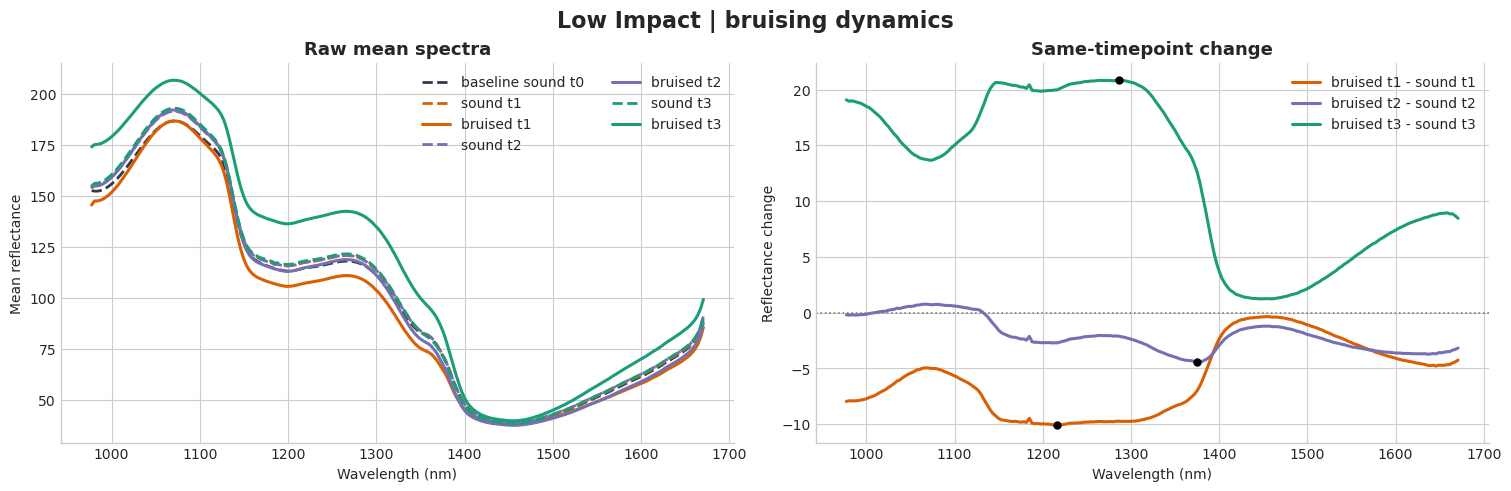

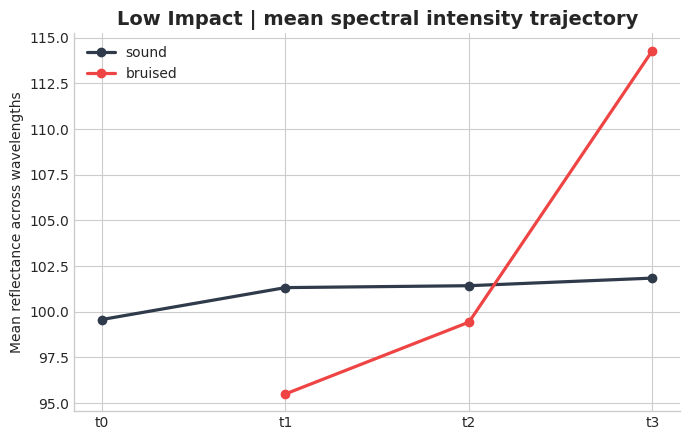

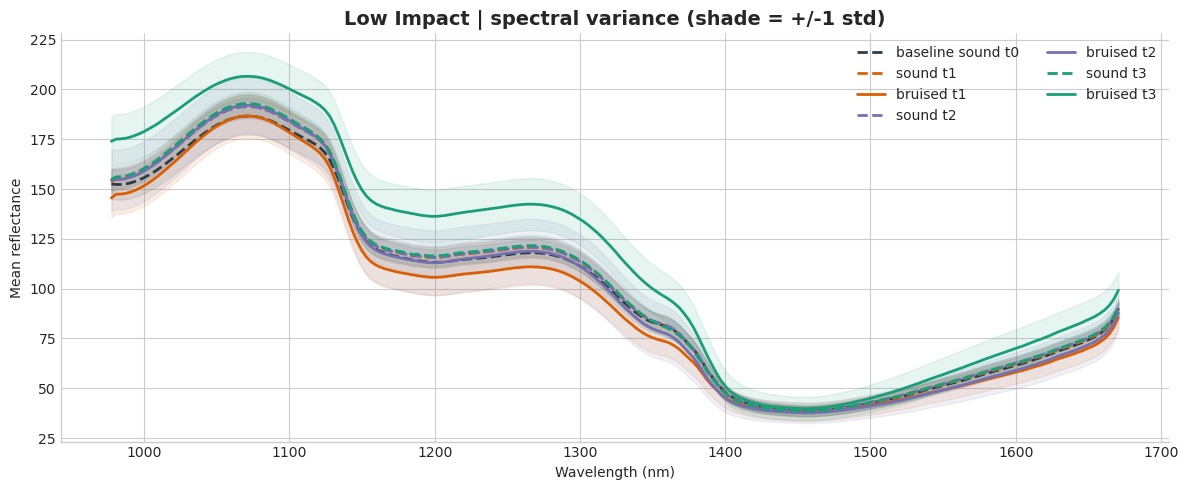

Non-overlap top wavelengths for low_impact: {'bands': [97, 96, 98, 90, 93, 91, 94, 92, 89, 99], 'scores': [20.833221435546875, 20.83123016357422, 20.822463989257812, 20.821510314941406, 20.814117431640625, 20.811767578125, 20.809982299804688, 20.80536651611328, 20.79876708984375, 20.7935791015625], 'timepoints': ['t3', 't3', 't3', 't3', 't3', 't3', 't3', 't3', 't3', 't3']}

Impact group: Medium Impact | n=36


processed-box spectra: 100%|██████████| 36/36 [00:49<00:00,  1.37s/sample]


ROI / pixel counts used per timepoint:
  t0: baseline_sound_boxes=288, baseline_sound_pixels=7372800, bruised_boxes=0, bruised_pixels=0, n_samples=36
  t1: sound_boxes=144, sound_pixels=3686400, bruised_boxes=144, bruised_pixels=57600, n_samples=36
  t2: sound_boxes=144, sound_pixels=3686400, bruised_boxes=144, bruised_pixels=57600, n_samples=36
  t3: sound_boxes=144, sound_pixels=3686400, bruised_boxes=144, bruised_pixels=57600, n_samples=36
[Medium Impact] Top 10 changing wavelengths: sound t1 vs bruised t1
1. wavelength=1216.5 nm: |Δ|=9.402374
2. wavelength=1219.7 nm: |Δ|=9.372208
3. wavelength=1213.4 nm: |Δ|=9.352715
4. wavelength=1222.9 nm: |Δ|=9.348206
5. wavelength=1226.1 nm: |Δ|=9.340424
6. wavelength=1210.2 nm: |Δ|=9.328270
7. wavelength=1207.0 nm: |Δ|=9.289612
8. wavelength=1229.2 nm: |Δ|=9.277115
9. wavelength=1203.8 nm: |Δ|=9.274300
10. wavelength=1242.0 nm: |Δ|=9.266144


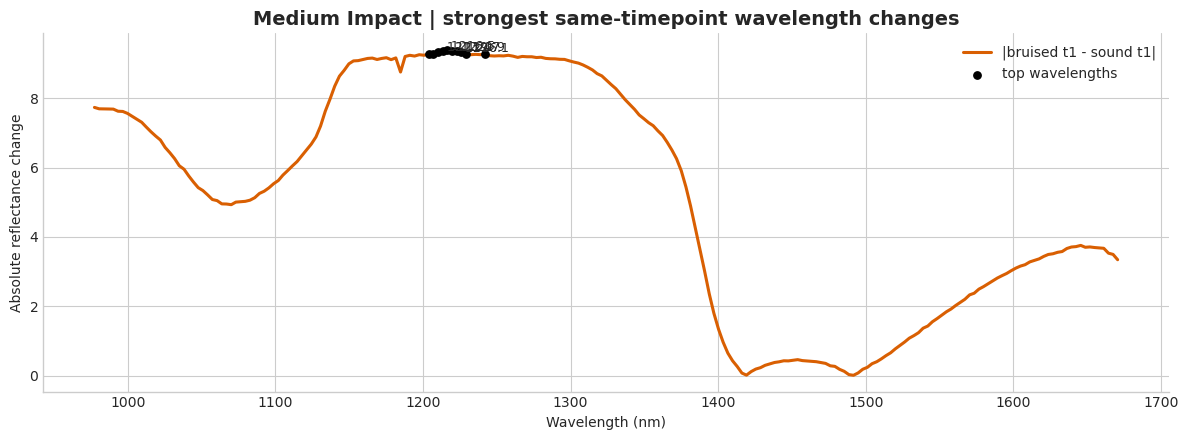

[Medium Impact] Top 10 changing wavelengths: sound t2 vs bruised t2
1. wavelength=1330.7 nm: |Δ|=7.677109
2. wavelength=1327.5 nm: |Δ|=7.659721
3. wavelength=1333.9 nm: |Δ|=7.652260
4. wavelength=1340.2 nm: |Δ|=7.636971
5. wavelength=1337.0 nm: |Δ|=7.631859
6. wavelength=1343.4 nm: |Δ|=7.623344
7. wavelength=1324.4 nm: |Δ|=7.616585
8. wavelength=1216.5 nm: |Δ|=7.606491
9. wavelength=1321.2 nm: |Δ|=7.591095
10. wavelength=1356.0 nm: |Δ|=7.584892


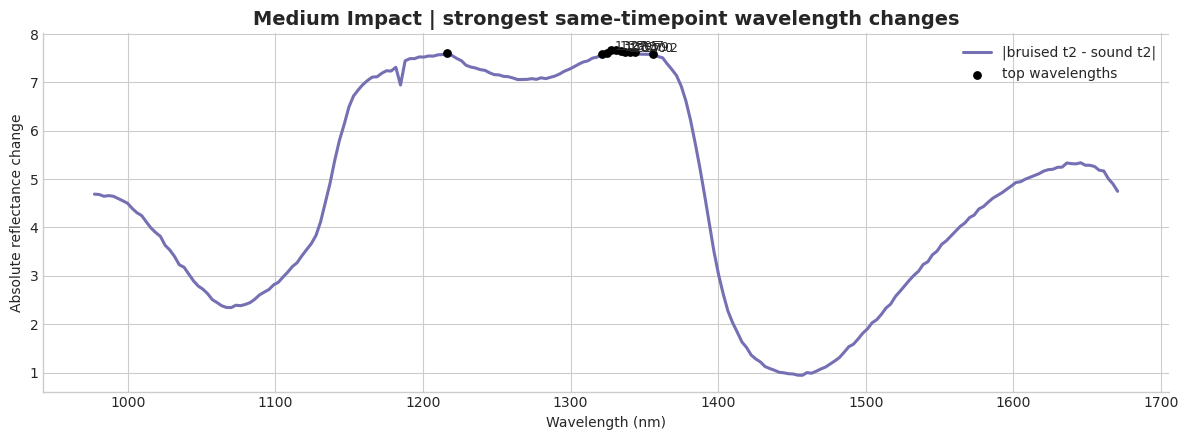

[Medium Impact] Top 10 changing wavelengths: sound t3 vs bruised t3
1. wavelength=1137.0 nm: |Δ|=11.815414
2. wavelength=1140.2 nm: |Δ|=11.796555
3. wavelength=1133.8 nm: |Δ|=11.661972
4. wavelength=1143.4 nm: |Δ|=11.658463
5. wavelength=977.4 nm: |Δ|=11.619934
6. wavelength=983.8 nm: |Δ|=11.577026
7. wavelength=987.0 nm: |Δ|=11.556396
8. wavelength=993.4 nm: |Δ|=11.542679
9. wavelength=990.2 nm: |Δ|=11.542496
10. wavelength=980.6 nm: |Δ|=11.537949


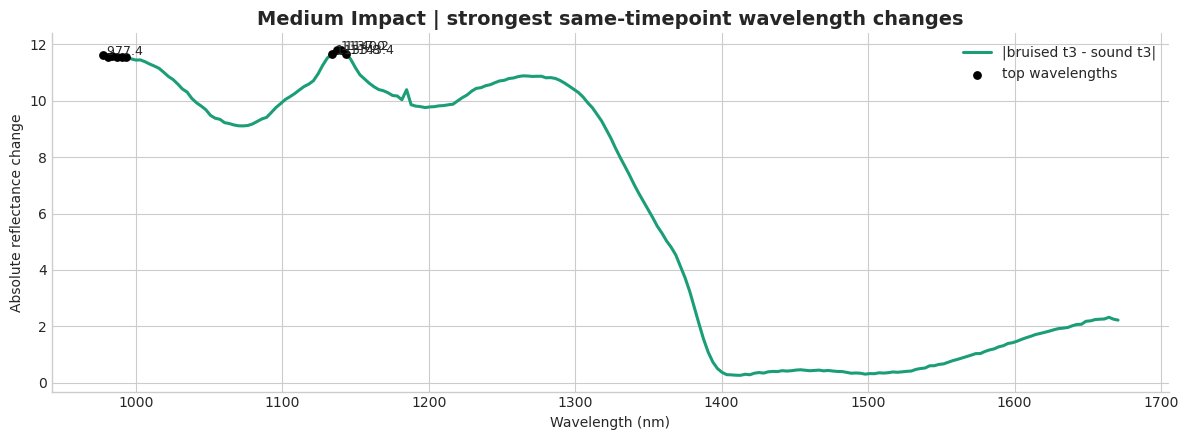

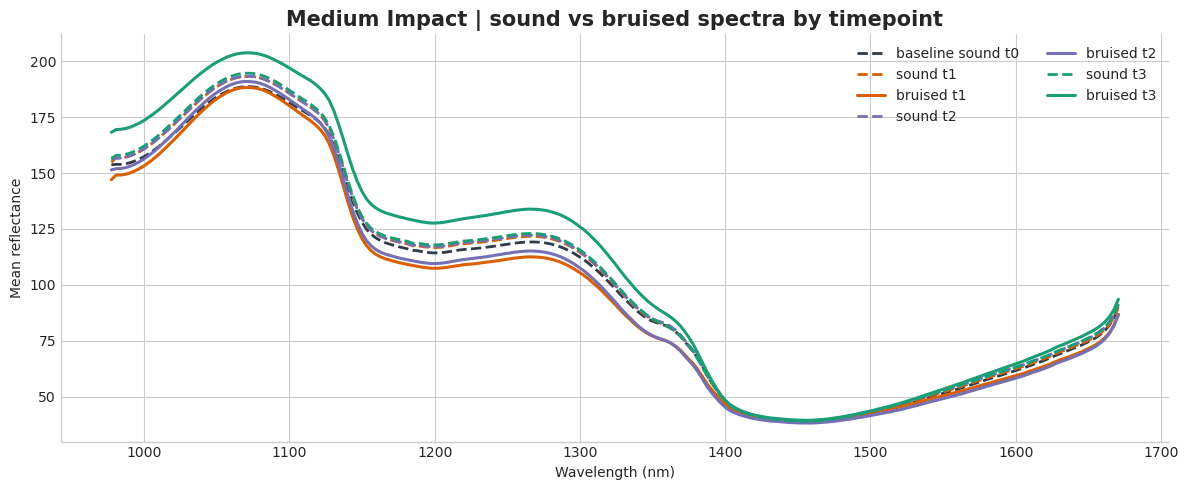

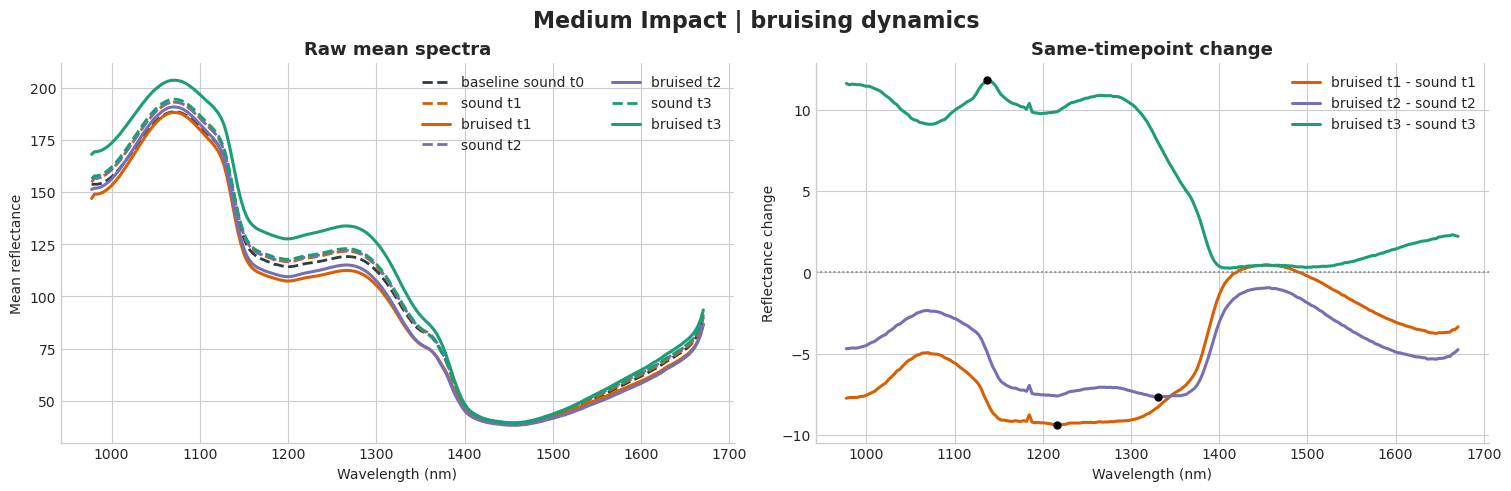

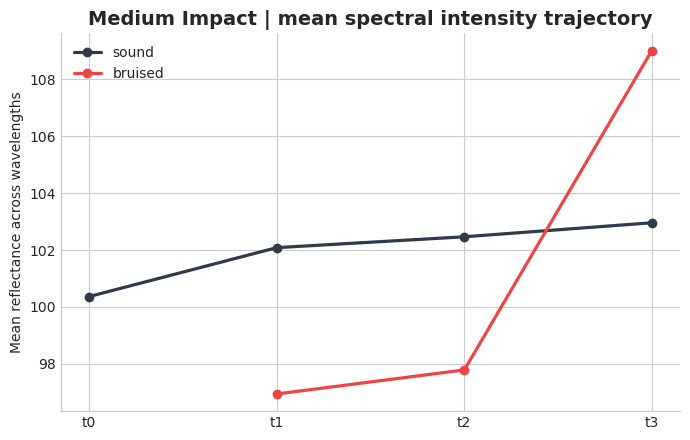

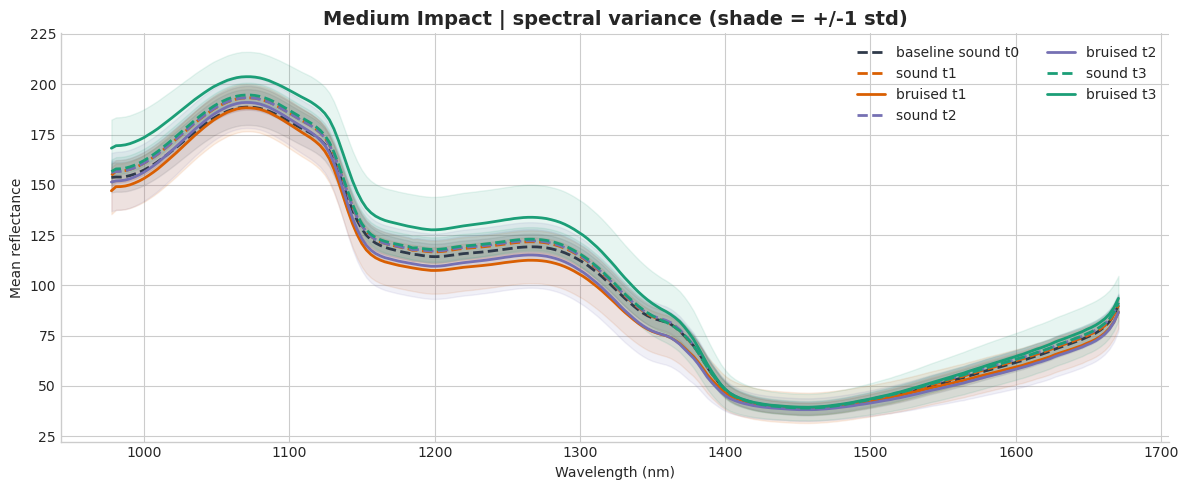

No wavelengths satisfy the non-overlap condition.
Non-overlap top wavelengths for medium_impact: {'bands': [], 'scores': [], 'timepoints': []}

Impact group: High Impact | n=36


processed-box spectra: 100%|██████████| 36/36 [00:49<00:00,  1.38s/sample]


ROI / pixel counts used per timepoint:
  t0: baseline_sound_boxes=288, baseline_sound_pixels=7372800, bruised_boxes=0, bruised_pixels=0, n_samples=36
  t1: sound_boxes=144, sound_pixels=3686400, bruised_boxes=144, bruised_pixels=57600, n_samples=36
  t2: sound_boxes=144, sound_pixels=3686400, bruised_boxes=144, bruised_pixels=57600, n_samples=36
  t3: sound_boxes=144, sound_pixels=3686400, bruised_boxes=144, bruised_pixels=57600, n_samples=36
[High Impact] Top 10 changing wavelengths: sound t1 vs bruised t1
1. wavelength=1257.8 nm: |Δ|=18.228149
2. wavelength=1267.3 nm: |Δ|=18.220932
3. wavelength=1273.7 nm: |Δ|=18.220375
4. wavelength=1270.5 nm: |Δ|=18.219803
5. wavelength=1261.0 nm: |Δ|=18.206581
6. wavelength=1254.6 nm: |Δ|=18.194061
7. wavelength=1264.2 nm: |Δ|=18.184738
8. wavelength=1276.9 nm: |Δ|=18.177780
9. wavelength=1280.0 nm: |Δ|=18.169083
10. wavelength=1251.5 nm: |Δ|=18.167252


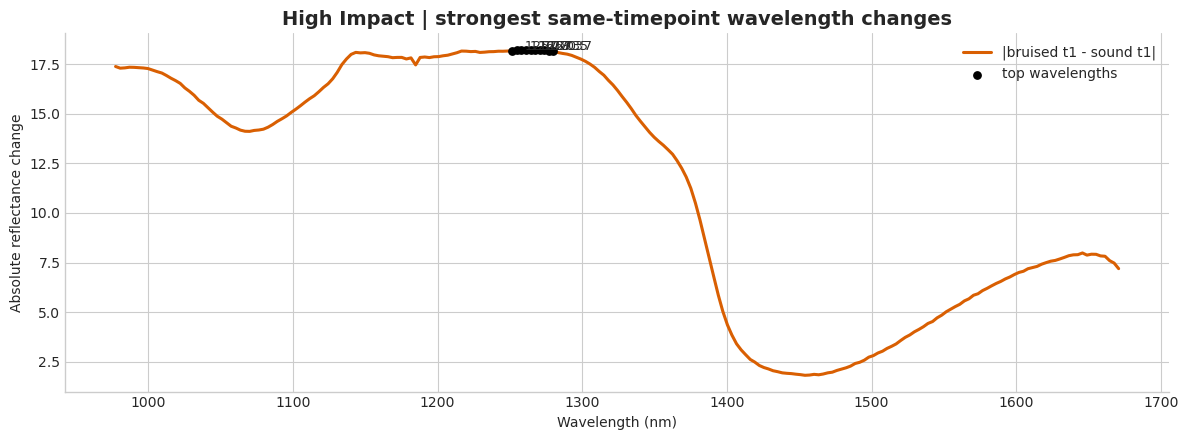

[High Impact] Top 10 changing wavelengths: sound t2 vs bruised t2
1. wavelength=1257.8 nm: |Δ|=30.934540
2. wavelength=1270.5 nm: |Δ|=30.931915
3. wavelength=1261.0 nm: |Δ|=30.927071
4. wavelength=1267.3 nm: |Δ|=30.923683
5. wavelength=1273.7 nm: |Δ|=30.921951
6. wavelength=1254.6 nm: |Δ|=30.914436
7. wavelength=1280.0 nm: |Δ|=30.905632
8. wavelength=1276.9 nm: |Δ|=30.900276
9. wavelength=1251.5 nm: |Δ|=30.898056
10. wavelength=1242.0 nm: |Δ|=30.894691


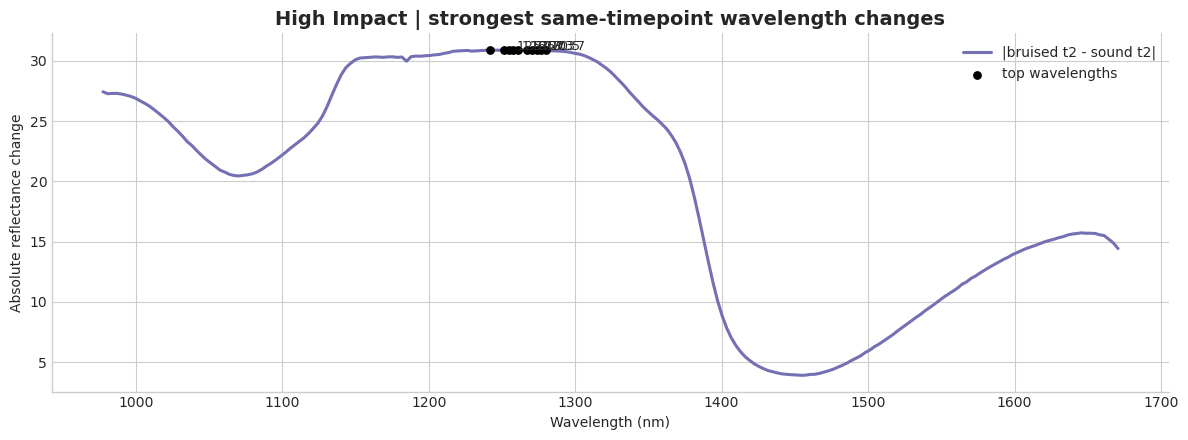

[High Impact] Top 10 changing wavelengths: sound t3 vs bruised t3
1. wavelength=1327.5 nm: |Δ|=20.462837
2. wavelength=1330.7 nm: |Δ|=20.459091
3. wavelength=1324.4 nm: |Δ|=20.442375
4. wavelength=1333.9 nm: |Δ|=20.423210
5. wavelength=1321.2 nm: |Δ|=20.392197
6. wavelength=1337.0 nm: |Δ|=20.325241
7. wavelength=1318.0 nm: |Δ|=20.276962
8. wavelength=1340.2 nm: |Δ|=20.268158
9. wavelength=1314.9 nm: |Δ|=20.232407
10. wavelength=1343.4 nm: |Δ|=20.153038


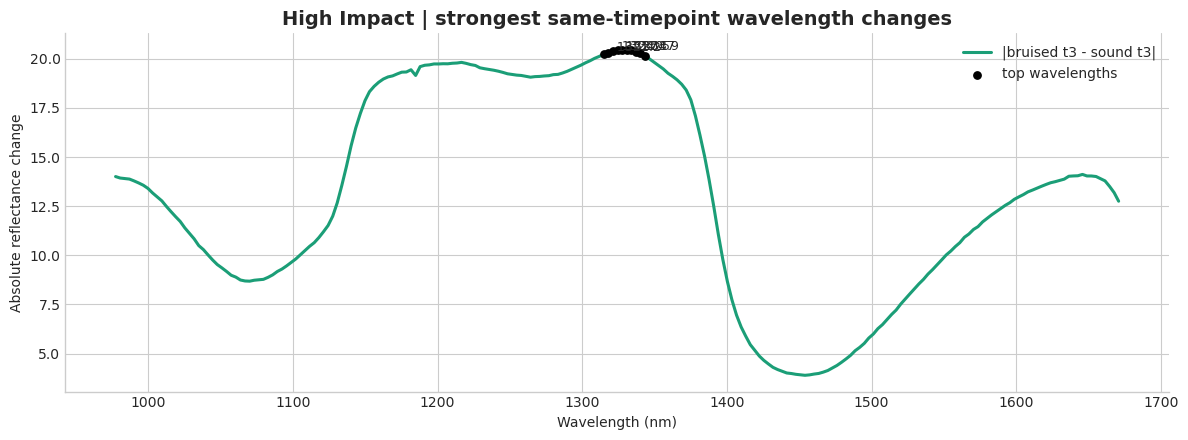

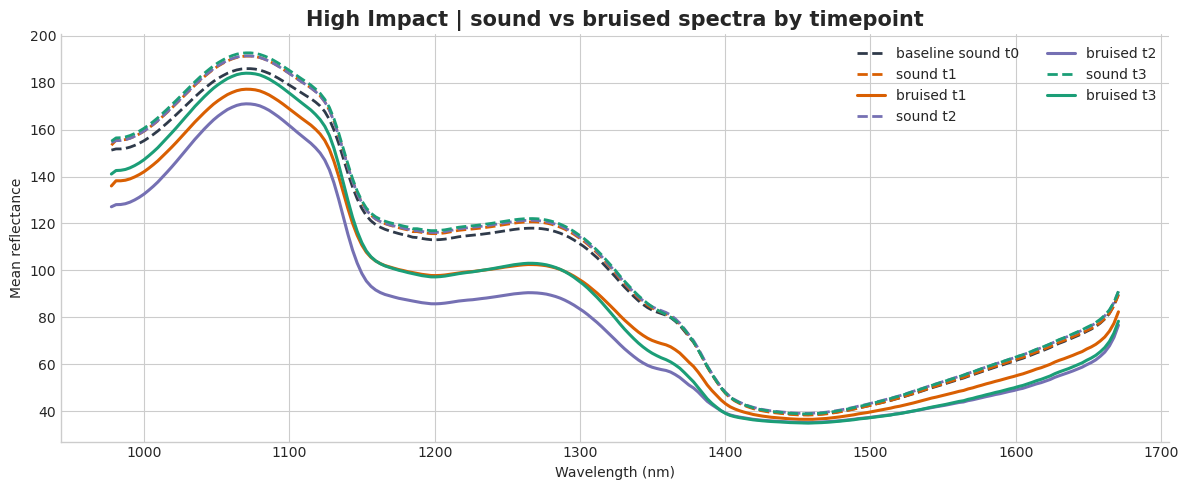

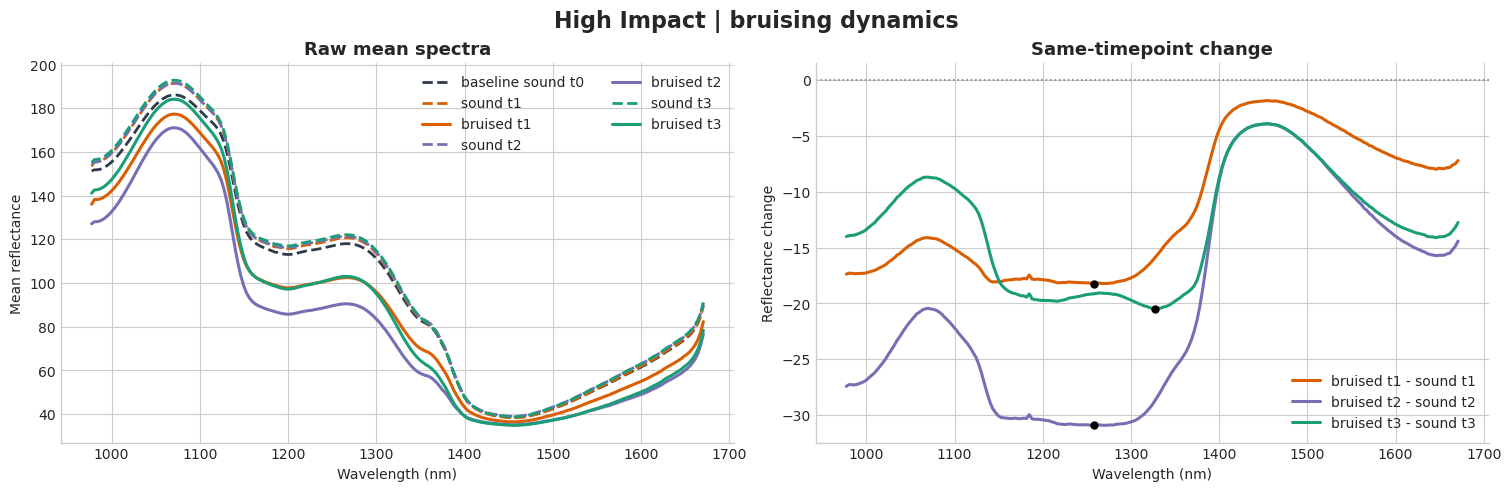

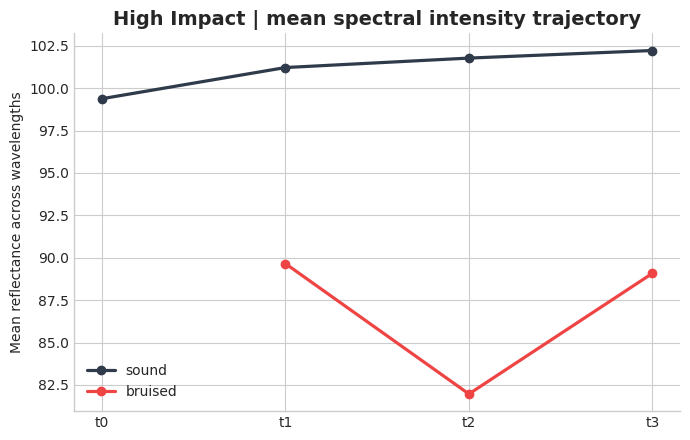

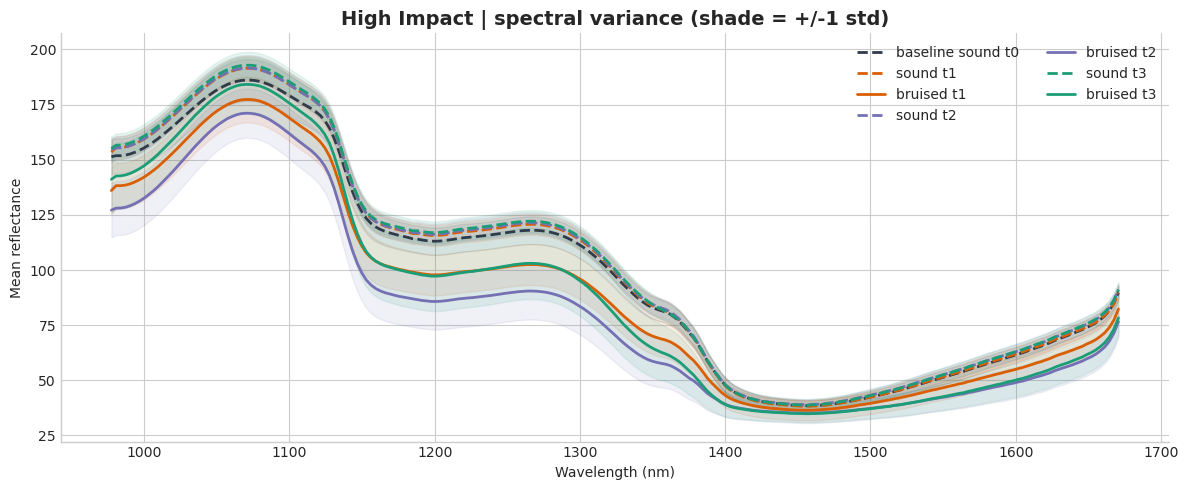

Non-overlap top wavelengths for high_impact: {'bands': [88, 92, 89, 91, 93, 87, 95, 94, 86, 83], 'scores': [30.93456268310547, 30.931915283203125, 30.927085876464844, 30.923660278320312, 30.921966552734375, 30.91443634033203, 30.90557861328125, 30.900299072265625, 30.898056030273438, 30.894683837890625], 'timepoints': ['t2', 't2', 't2', 't2', 't2', 't2', 't2', 't2', 't2', 't2']}


In [45]:
IMPACT_RESULTS = {}
for group_name in ['low_impact', 'medium_impact', 'high_impact']:
    IMPACT_RESULTS[group_name] = run_full_group_analysis(
        group_name,
        REQUESTED_GROUPS[group_name],
        top_k=TOP_K,
        show_boxplots=False,
        section_label='Impact group',
    )


## Impact group analyses complete

Low-impact, medium-impact, and high-impact groups use `t0` as baseline-only sound tissue. Damaged-vs-sound comparisons start at `t1` and continue through `t3`.


## Warm, Cold, and Whole Train+Validation Analyses

These blocks use the same train+validation H5 files already loaded from `data/splits/train` and `data/splits/val`. Warm and cold condition groups are analyzed separately, and the whole-sample block uses every complete train+validation sample.


**Condition and whole-sample summary**

,condition_group,n_samples
0,warm_condition,52
1,cold_condition,54
2,all_train_val_samples,106


**Condition group x timepoint box counts**

,condition_group,timepoint,samples,sound_boxes,bruised_boxes
0,warm_condition,t0,52,416,0
1,warm_condition,t1,52,208,208
2,warm_condition,t2,52,208,208
3,warm_condition,t3,52,208,208
4,cold_condition,t0,54,432,0
5,cold_condition,t1,54,216,216
6,cold_condition,t2,54,216,216
7,cold_condition,t3,54,216,216
8,all_train_val_samples,t0,106,848,0
9,all_train_val_samples,t1,106,424,424



Condition group: Warm Condition | n=52


processed-box spectra: 100%|██████████| 52/52 [01:09<00:00,  1.33s/sample]


ROI / pixel counts used per timepoint:
  t0: baseline_sound_boxes=416, baseline_sound_pixels=10649600, bruised_boxes=0, bruised_pixels=0, n_samples=52
  t1: sound_boxes=208, sound_pixels=5324800, bruised_boxes=208, bruised_pixels=83200, n_samples=52
  t2: sound_boxes=208, sound_pixels=5324800, bruised_boxes=208, bruised_pixels=83200, n_samples=52
  t3: sound_boxes=208, sound_pixels=5324800, bruised_boxes=208, bruised_pixels=83200, n_samples=52
[Warm Condition] Top 10 changing wavelengths: sound t1 vs bruised t1
1. wavelength=1216.5 nm: |Δ|=14.720070
2. wavelength=1219.7 nm: |Δ|=14.711815
3. wavelength=1226.1 nm: |Δ|=14.699265
4. wavelength=1222.9 nm: |Δ|=14.697960
5. wavelength=1242.0 nm: |Δ|=14.668999
6. wavelength=1235.6 nm: |Δ|=14.667786
7. wavelength=1257.8 nm: |Δ|=14.664818
8. wavelength=1213.4 nm: |Δ|=14.656853
9. wavelength=1273.7 nm: |Δ|=14.656136
10. wavelength=1232.4 nm: |Δ|=14.654808


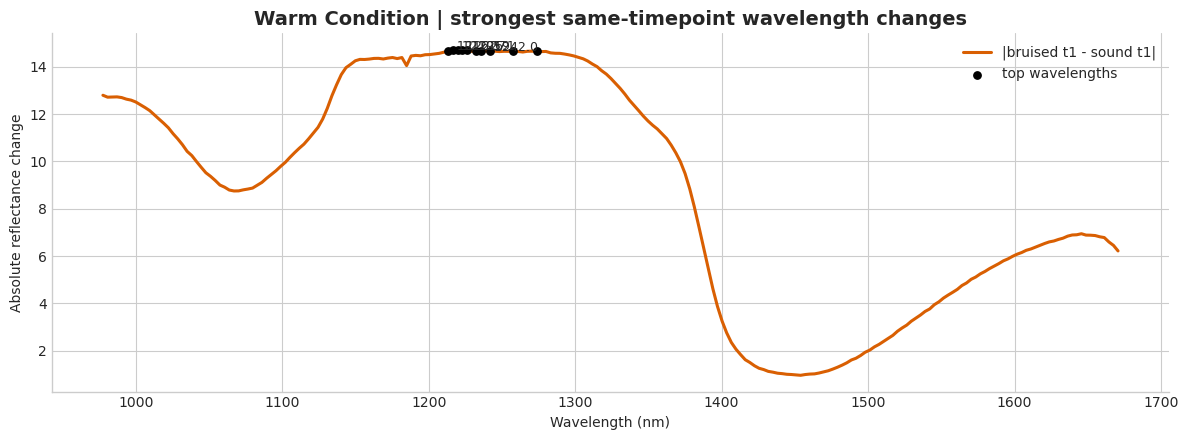

[Warm Condition] Top 10 changing wavelengths: sound t2 vs bruised t2
1. wavelength=1216.5 nm: |Δ|=13.708290
2. wavelength=1219.7 nm: |Δ|=13.689751
3. wavelength=1222.9 nm: |Δ|=13.661530
4. wavelength=1213.4 nm: |Δ|=13.660034
5. wavelength=1226.1 nm: |Δ|=13.646790
6. wavelength=1210.2 nm: |Δ|=13.635536
7. wavelength=1308.5 nm: |Δ|=13.600922
8. wavelength=1203.8 nm: |Δ|=13.598335
9. wavelength=1305.4 nm: |Δ|=13.596245
10. wavelength=1207.0 nm: |Δ|=13.592758


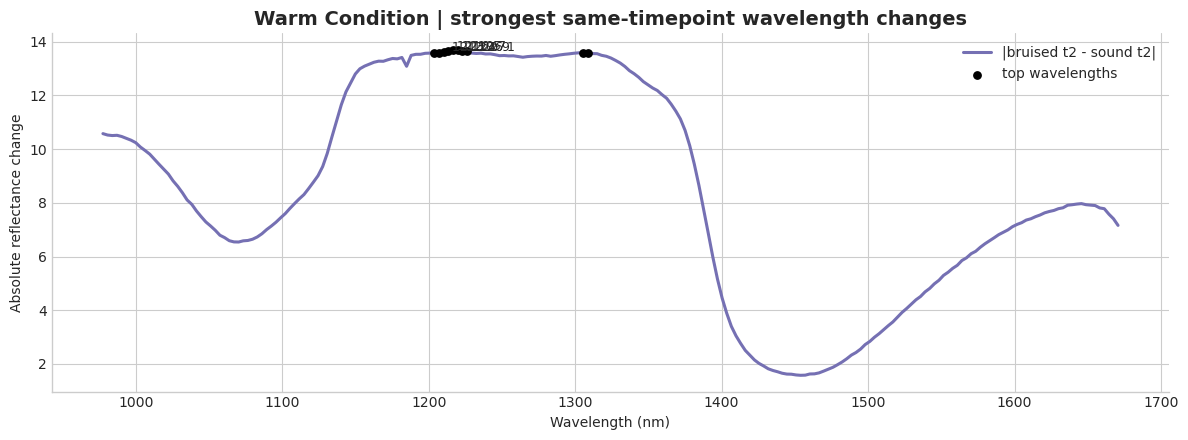

[Warm Condition] Top 10 changing wavelengths: sound t3 vs bruised t3
1. wavelength=1127.5 nm: |Δ|=6.137726
2. wavelength=1124.3 nm: |Δ|=6.111725
3. wavelength=1015.7 nm: |Δ|=6.090881
4. wavelength=1130.6 nm: |Δ|=6.084595
5. wavelength=1018.9 nm: |Δ|=6.073761
6. wavelength=1034.9 nm: |Δ|=6.067261
7. wavelength=1025.3 nm: |Δ|=6.065338
8. wavelength=1012.5 nm: |Δ|=6.061722
9. wavelength=1114.7 nm: |Δ|=6.055832
10. wavelength=1022.1 nm: |Δ|=6.047409


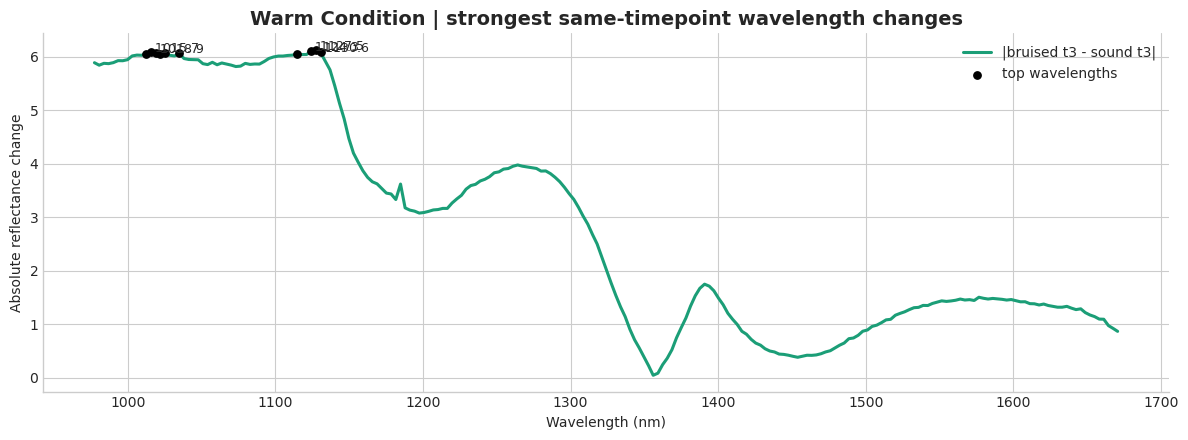

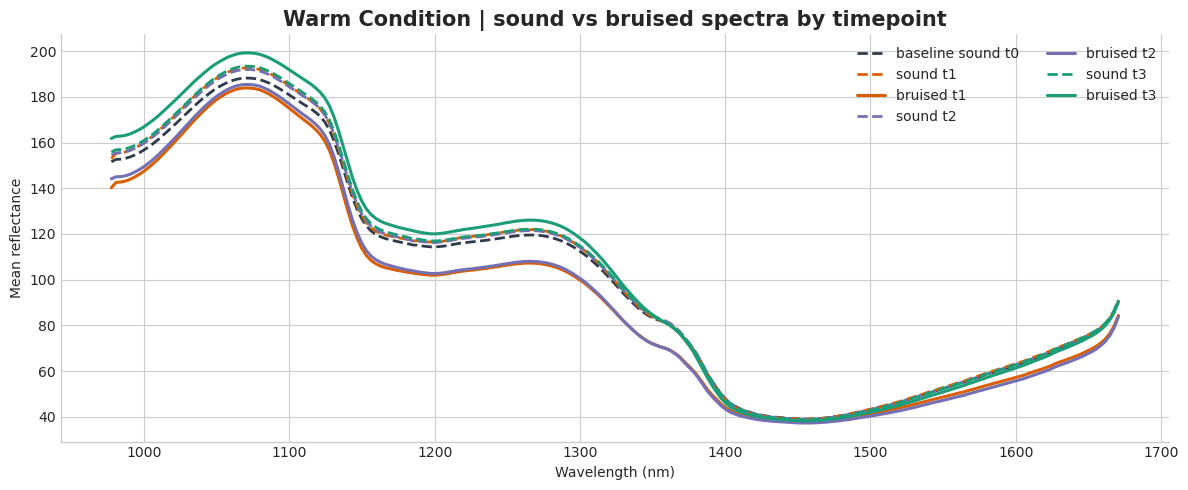

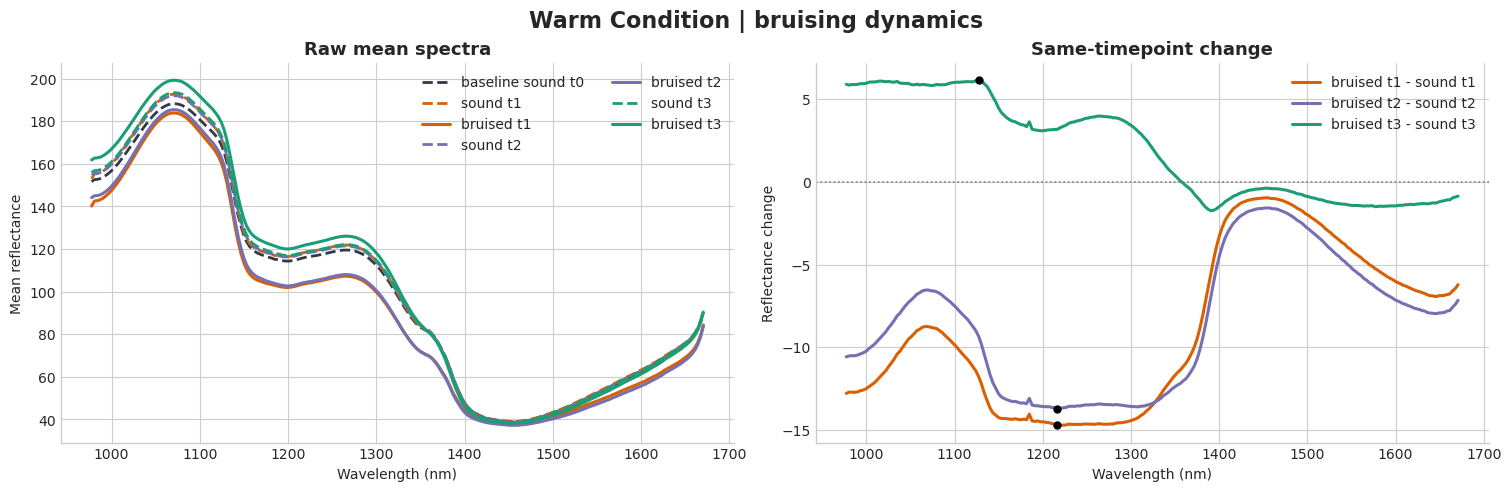

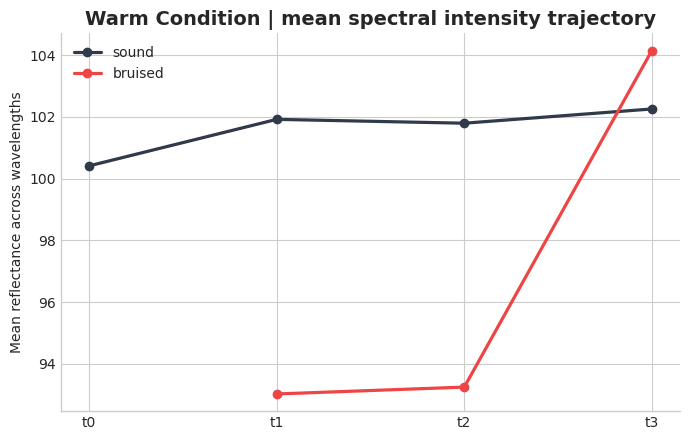

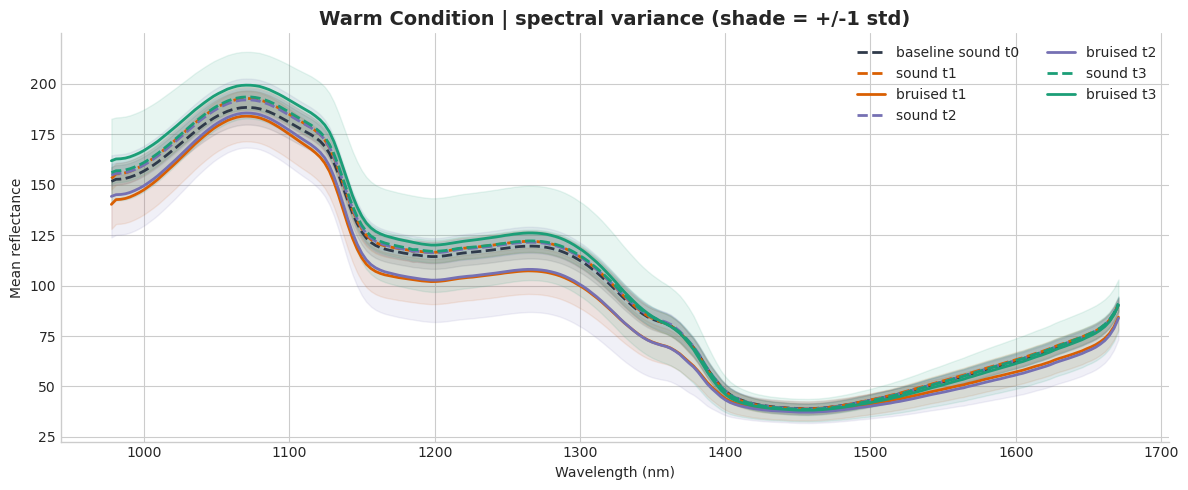

No wavelengths satisfy the non-overlap condition.
Non-overlap top wavelengths for warm_condition: {'bands': [], 'scores': [], 'timepoints': []}

Condition group: Cold Condition | n=54


processed-box spectra: 100%|██████████| 54/54 [01:10<00:00,  1.31s/sample]


ROI / pixel counts used per timepoint:
  t0: baseline_sound_boxes=432, baseline_sound_pixels=11059200, bruised_boxes=0, bruised_pixels=0, n_samples=54
  t1: sound_boxes=216, sound_pixels=5529600, bruised_boxes=216, bruised_pixels=86400, n_samples=54
  t2: sound_boxes=216, sound_pixels=5529600, bruised_boxes=216, bruised_pixels=86400, n_samples=54
  t3: sound_boxes=216, sound_pixels=5529600, bruised_boxes=216, bruised_pixels=86400, n_samples=54
[Cold Condition] Top 10 changing wavelengths: sound t1 vs bruised t1
1. wavelength=1216.5 nm: |Δ|=10.562454
2. wavelength=1219.7 nm: |Δ|=10.524452
3. wavelength=1213.4 nm: |Δ|=10.514626
4. wavelength=1222.9 nm: |Δ|=10.483803
5. wavelength=1210.2 nm: |Δ|=10.480530
6. wavelength=1226.1 nm: |Δ|=10.461899
7. wavelength=1207.0 nm: |Δ|=10.437355
8. wavelength=1203.8 nm: |Δ|=10.426437
9. wavelength=1197.5 nm: |Δ|=10.406265
10. wavelength=1191.1 nm: |Δ|=10.391098


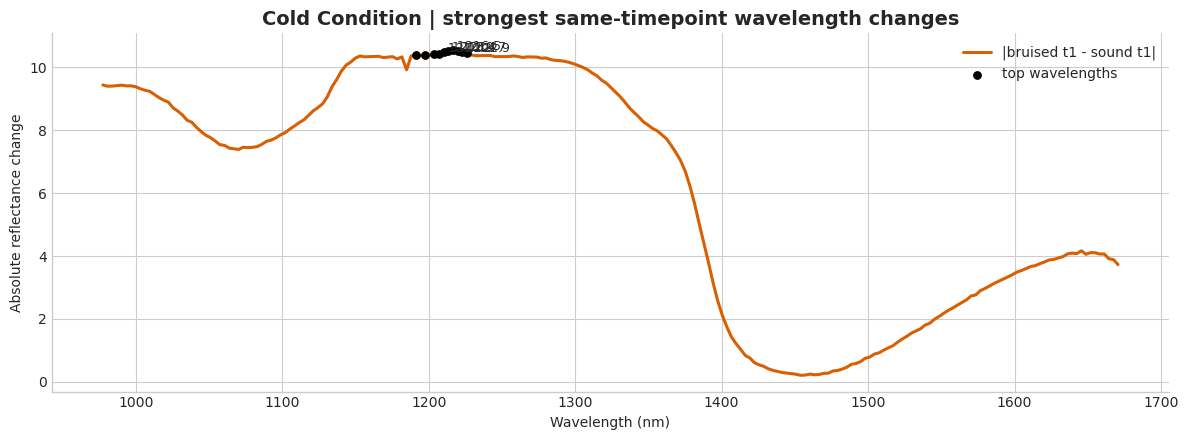

[Cold Condition] Top 10 changing wavelengths: sound t2 vs bruised t2
1. wavelength=1216.5 nm: |Δ|=14.109367
2. wavelength=1219.7 nm: |Δ|=14.065529
3. wavelength=1213.4 nm: |Δ|=14.058037
4. wavelength=1210.2 nm: |Δ|=14.038078
5. wavelength=1222.9 nm: |Δ|=14.022026
6. wavelength=1207.0 nm: |Δ|=13.984306
7. wavelength=1226.1 nm: |Δ|=13.982681
8. wavelength=1203.8 nm: |Δ|=13.969772
9. wavelength=1197.5 nm: |Δ|=13.934189
10. wavelength=1200.7 nm: |Δ|=13.931862


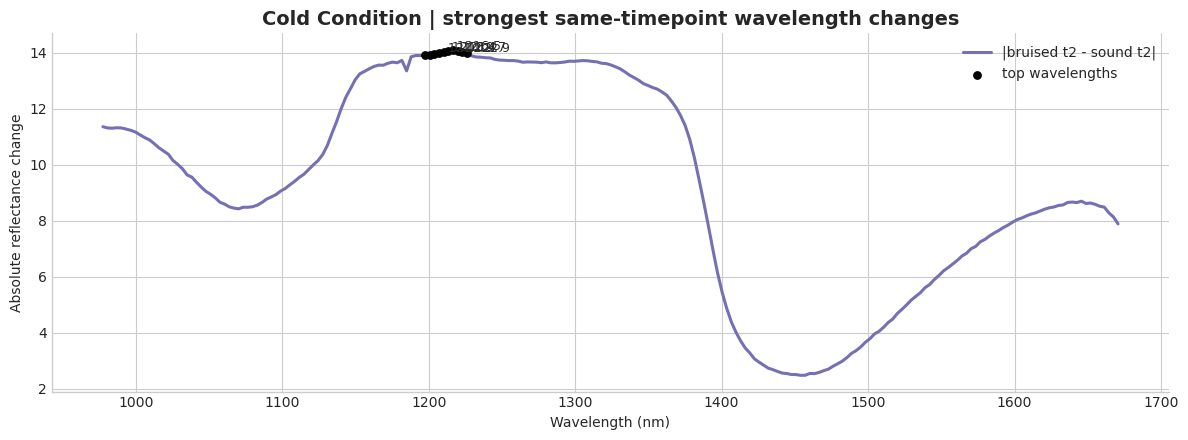

[Cold Condition] Top 10 changing wavelengths: sound t3 vs bruised t3
1. wavelength=1137.0 nm: |Δ|=4.930801
2. wavelength=1133.8 nm: |Δ|=4.868744
3. wavelength=1140.2 nm: |Δ|=4.843750
4. wavelength=1130.6 nm: |Δ|=4.803131
5. wavelength=977.4 nm: |Δ|=4.749054
6. wavelength=983.8 nm: |Δ|=4.740387
7. wavelength=987.0 nm: |Δ|=4.710709
8. wavelength=980.6 nm: |Δ|=4.704895
9. wavelength=990.2 nm: |Δ|=4.696609
10. wavelength=1143.4 nm: |Δ|=4.691574


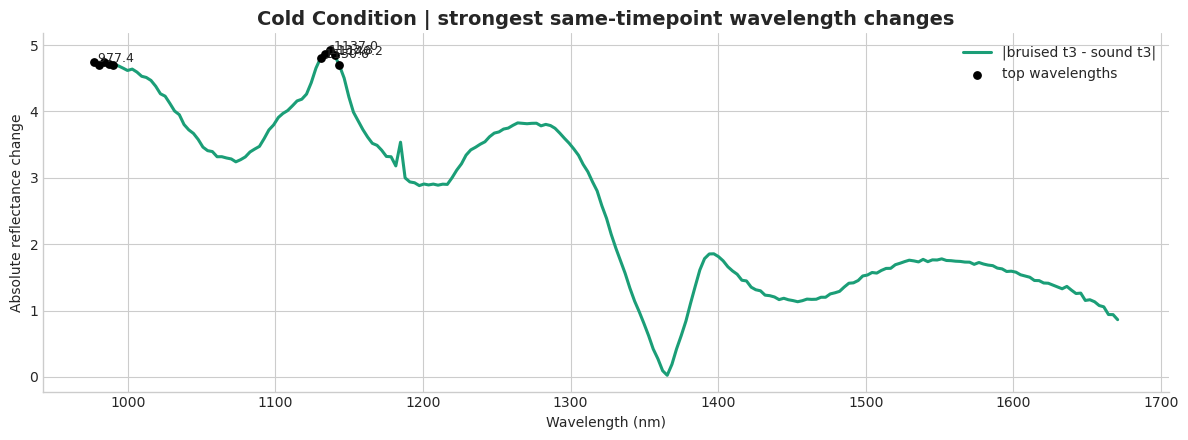

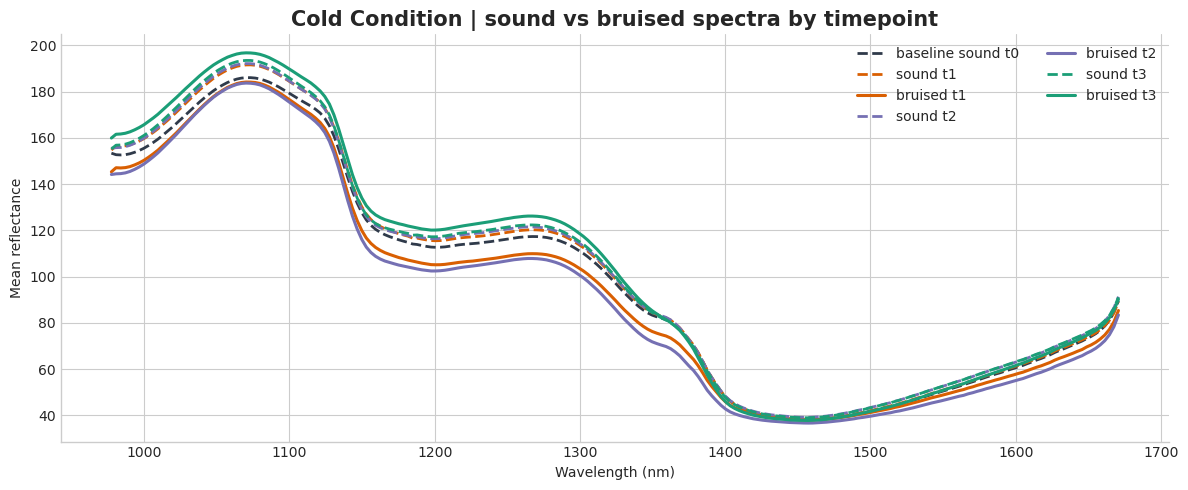

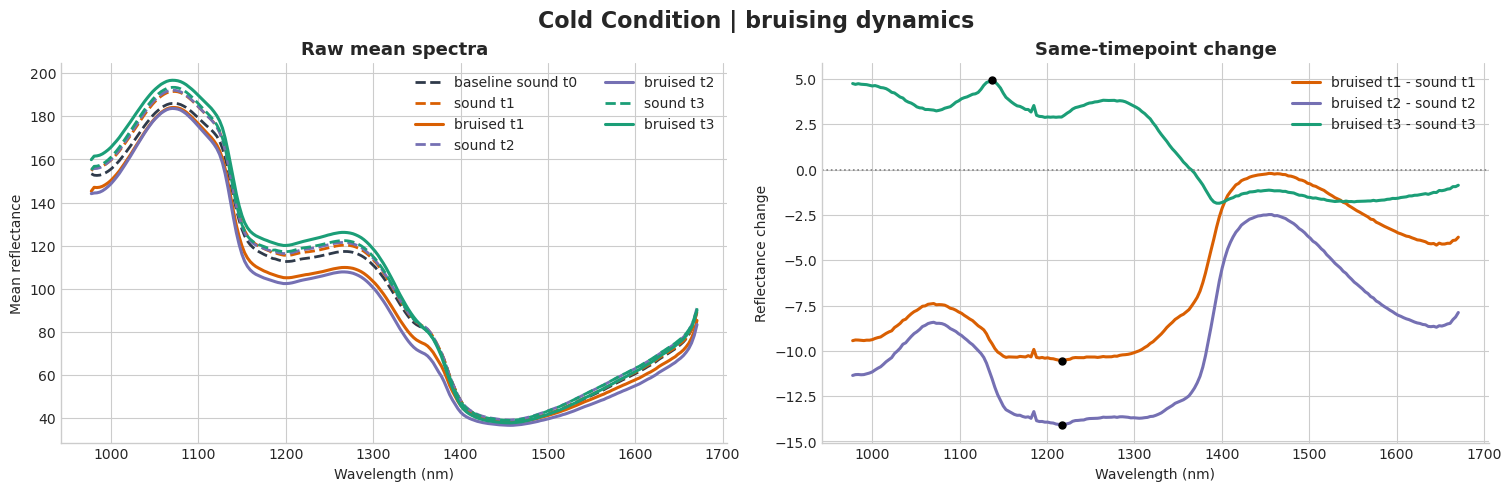

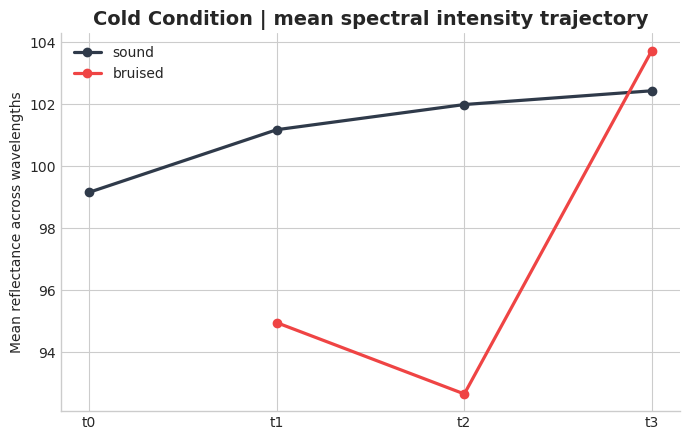

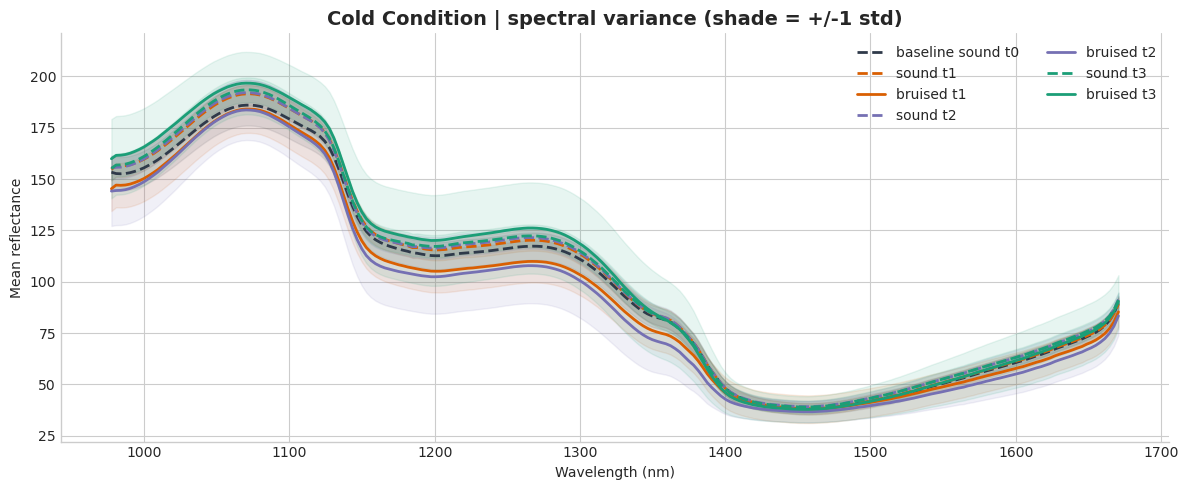

No wavelengths satisfy the non-overlap condition.
Non-overlap top wavelengths for cold_condition: {'bands': [], 'scores': [], 'timepoints': []}

Whole train+validation sample: All Train+Validation Samples | n=106


processed-box spectra: 100%|██████████| 106/106 [02:21<00:00,  1.33s/sample]


ROI / pixel counts used per timepoint:
  t0: baseline_sound_boxes=848, baseline_sound_pixels=21708800, bruised_boxes=0, bruised_pixels=0, n_samples=106
  t1: sound_boxes=424, sound_pixels=10854400, bruised_boxes=424, bruised_pixels=169600, n_samples=106
  t2: sound_boxes=424, sound_pixels=10854400, bruised_boxes=424, bruised_pixels=169600, n_samples=106
  t3: sound_boxes=424, sound_pixels=10854400, bruised_boxes=424, bruised_pixels=169600, n_samples=106
[All Train+Validation Samples] Top 10 changing wavelengths: sound t1 vs bruised t1
1. wavelength=1216.5 nm: |Δ|=12.602043
2. wavelength=1219.7 nm: |Δ|=12.578636
3. wavelength=1222.9 nm: |Δ|=12.551125
4. wavelength=1213.4 nm: |Δ|=12.546661
5. wavelength=1226.1 nm: |Δ|=12.540604
6. wavelength=1210.2 nm: |Δ|=12.506119
7. wavelength=1242.0 nm: |Δ|=12.482391
8. wavelength=1235.6 nm: |Δ|=12.480896
9. wavelength=1229.2 nm: |Δ|=12.478386
10. wavelength=1238.8 nm: |Δ|=12.473160


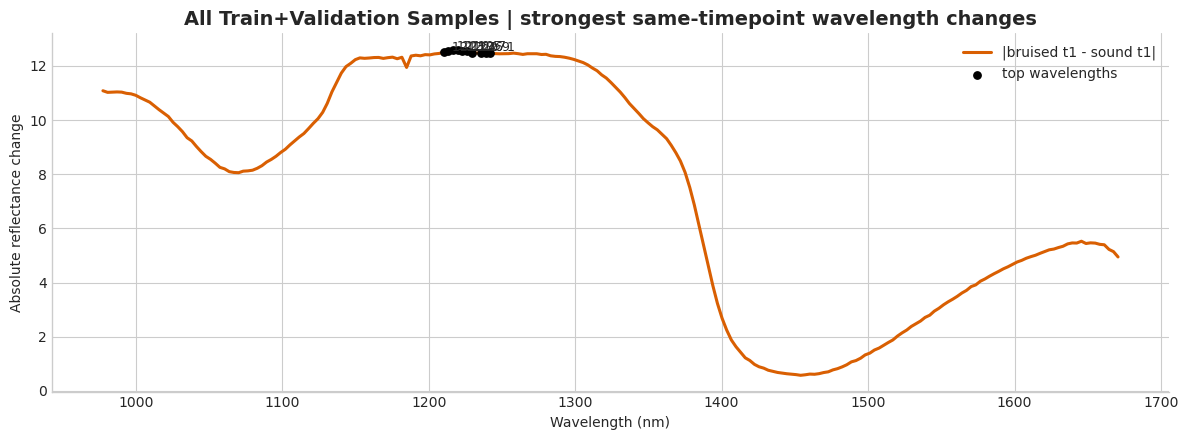

[All Train+Validation Samples] Top 10 changing wavelengths: sound t2 vs bruised t2
1. wavelength=1216.5 nm: |Δ|=13.912613
2. wavelength=1219.7 nm: |Δ|=13.881187
3. wavelength=1213.4 nm: |Δ|=13.862785
4. wavelength=1222.9 nm: |Δ|=13.845177
5. wavelength=1210.2 nm: |Δ|=13.840599
6. wavelength=1226.1 nm: |Δ|=13.817902
7. wavelength=1207.0 nm: |Δ|=13.792229
8. wavelength=1203.8 nm: |Δ|=13.787560
9. wavelength=1200.7 nm: |Δ|=13.758263
10. wavelength=1197.5 nm: |Δ|=13.756081


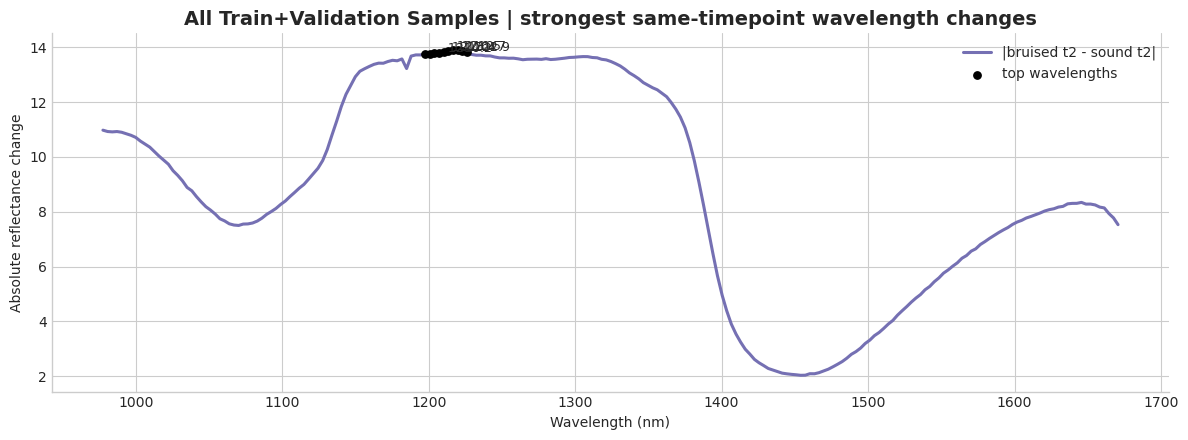

[All Train+Validation Samples] Top 10 changing wavelengths: sound t3 vs bruised t3
1. wavelength=1130.6 nm: |Δ|=5.431778
2. wavelength=1133.8 nm: |Δ|=5.385010
3. wavelength=1127.5 nm: |Δ|=5.380890
4. wavelength=1137.0 nm: |Δ|=5.337570
5. wavelength=1003.0 nm: |Δ|=5.315414
6. wavelength=977.4 nm: |Δ|=5.310150
7. wavelength=1006.2 nm: |Δ|=5.300232
8. wavelength=983.8 nm: |Δ|=5.300018
9. wavelength=993.4 nm: |Δ|=5.297913
10. wavelength=990.2 nm: |Δ|=5.284042


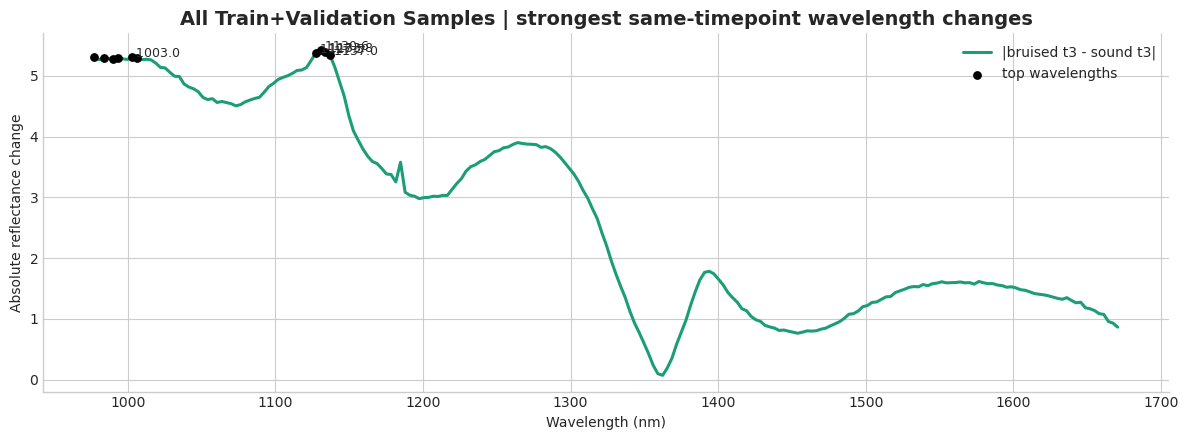

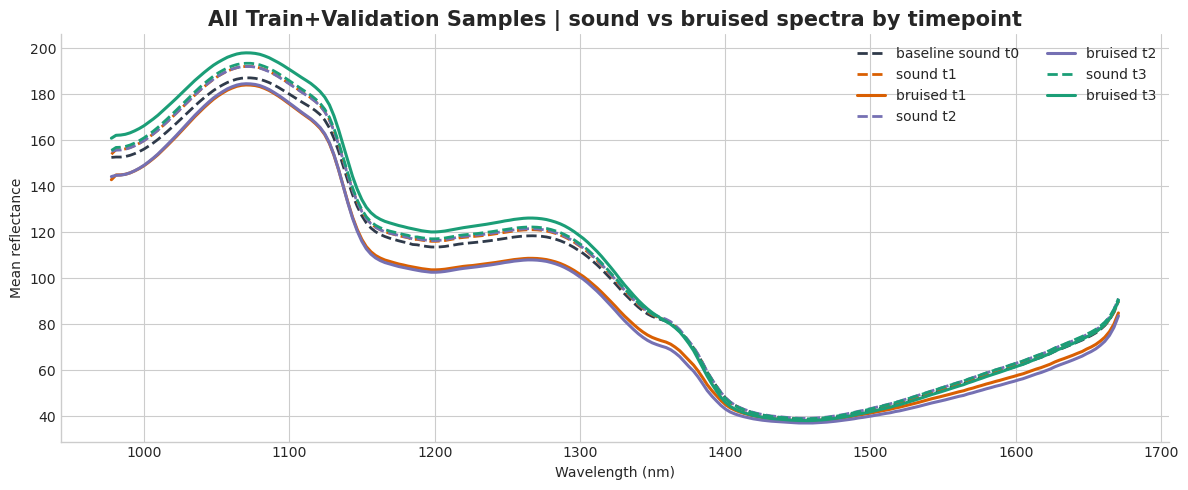

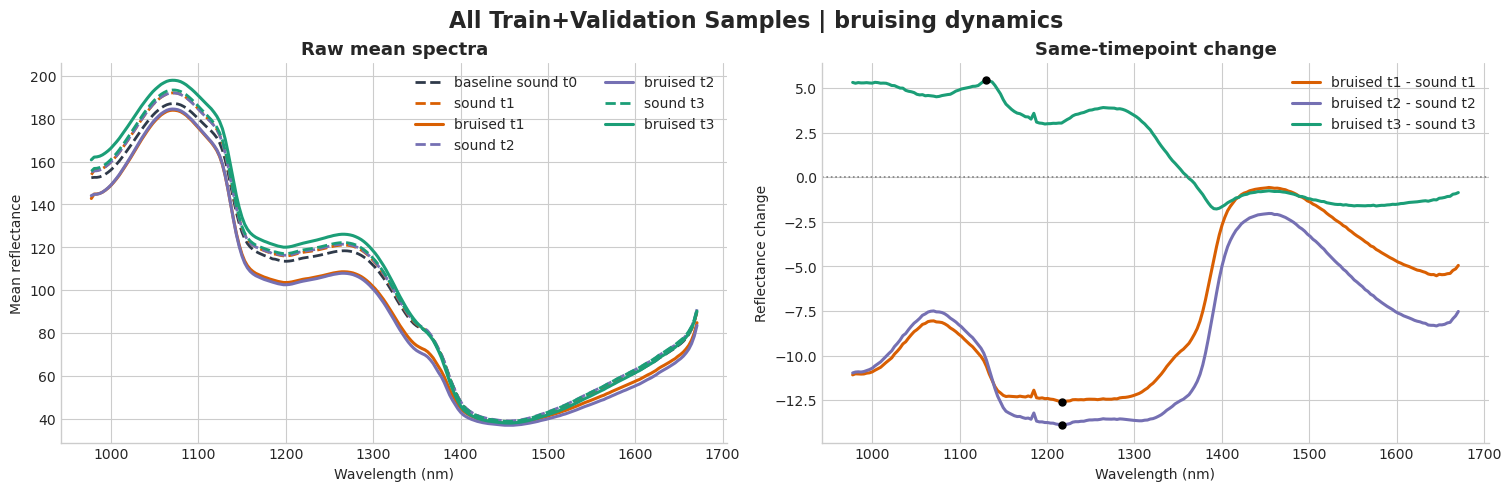

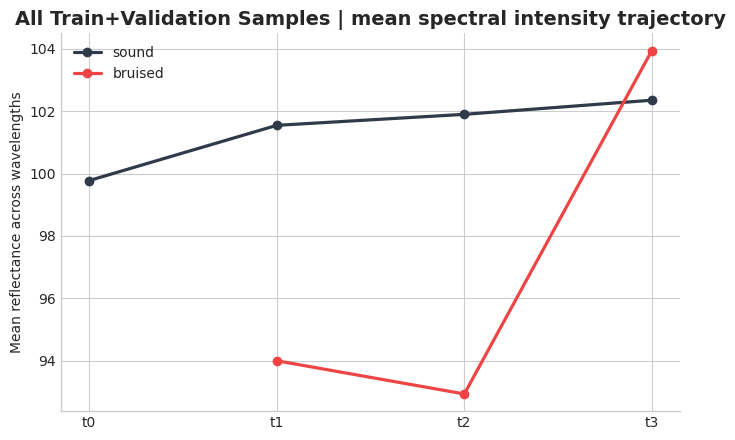

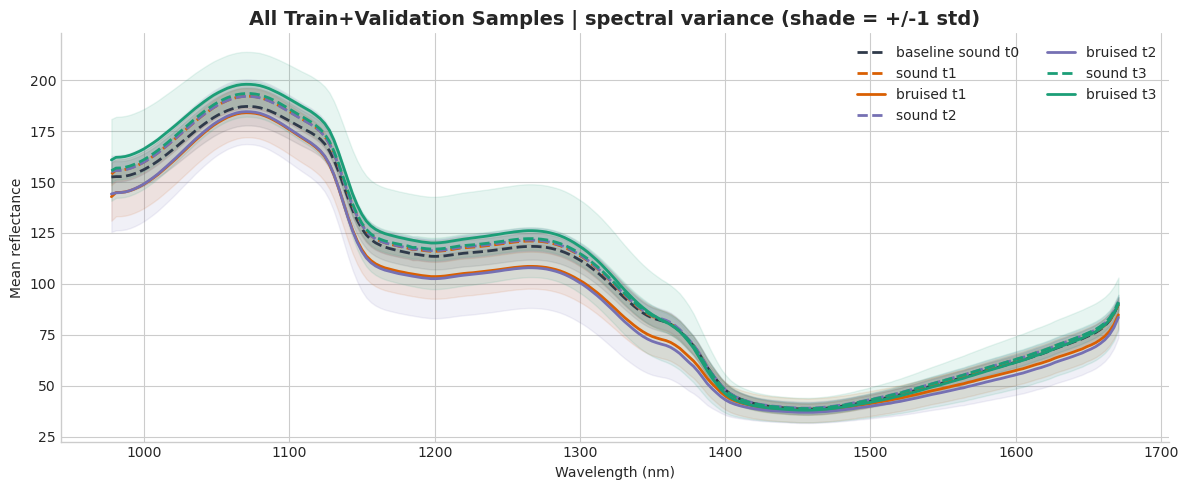

No wavelengths satisfy the non-overlap condition.
Non-overlap top wavelengths for all_train_val_samples: {'bands': [], 'scores': [], 'timepoints': []}


In [46]:
WARM_PREFIXES = ('28',)
COLD_PREFIXES = ('29',)

CONDITION_GROUPS = {
    'warm_condition': codes_for_prefixes(WARM_PREFIXES),
    'cold_condition': codes_for_prefixes(COLD_PREFIXES),
    'all_train_val_samples': sorted(complete_codes),
}

condition_summary_rows = []
condition_timepoint_rows = []
for name, codes in CONDITION_GROUPS.items():
    group_inventory = inventory_df[inventory_df['sample_code'].isin(codes)].copy()
    condition_summary_rows.append({
        'condition_group': name,
        'n_samples': len(codes),
    })
    for timepoint in TIMEPOINTS:
        subset = group_inventory[group_inventory['timepoint'] == timepoint]
        condition_timepoint_rows.append({
            'condition_group': name,
            'timepoint': timepoint,
            'samples': subset['sample_code'].nunique(),
            'sound_boxes': int(subset['sound_boxes'].sum()),
            'bruised_boxes': int(subset['bruised_boxes'].sum()) if timepoint in DAMAGED_TIMEPOINTS else 0,
        })

condition_summary_df = pd.DataFrame(condition_summary_rows)
condition_timepoint_df = pd.DataFrame(condition_timepoint_rows)

display(Markdown('**Condition and whole-sample summary**'))
display(condition_summary_df)

display(Markdown('**Condition group x timepoint box counts**'))
display(condition_timepoint_df)

CONDITION_RESULTS = {}
for group_name, sample_codes in CONDITION_GROUPS.items():
    label = 'Whole train+validation sample' if group_name == 'all_train_val_samples' else 'Condition group'
    CONDITION_RESULTS[group_name] = run_full_group_analysis(
        group_name,
        sample_codes,
        top_k=TOP_K,
        show_boxplots=False,
        section_label=label,
    )


In [47]:
# Simple same-timepoint healthy vs damaged comparison using paired sample-level means.
# t0 is baseline-only, so tests begin at t1.
from scipy import stats

SAMPLE_CODES_FOR_TESTS = sorted({code for codes in REQUESTED_GROUPS.values() for code in codes})

compare_rows = []
for sample_code in SAMPLE_CODES_FOR_TESTS:
    for timepoint in DAMAGED_TIMEPOINTS:
        sound_cubes = load_box_cubes(sample_code, timepoint, 'sound')
        bruised_cubes = load_box_cubes(sample_code, timepoint, 'bruised')
        sound_mean = np.stack([cube_band_values(cube).mean(axis=0) for cube in sound_cubes], axis=0).mean(axis=0)
        bruised_mean = np.stack([cube_band_values(cube).mean(axis=0) for cube in bruised_cubes], axis=0).mean(axis=0)
        compare_rows.append({
            'sample_code': sample_code,
            'timepoint': timepoint,
            'sound_mean': float(sound_mean.mean()),
            'bruised_mean': float(bruised_mean.mean()),
            'delta_bruised_minus_sound': float(bruised_mean.mean() - sound_mean.mean()),
        })

same_timepoint_compare_df = pd.DataFrame(compare_rows).sort_values(['sample_code', 'timepoint']).reset_index(drop=True)

test_rows = []
for timepoint, frame in same_timepoint_compare_df.groupby('timepoint', sort=False):
    sound_vals = frame['sound_mean'].to_numpy(dtype=float)
    bruised_vals = frame['bruised_mean'].to_numpy(dtype=float)
    paired_t = stats.ttest_rel(bruised_vals, sound_vals)
    wilcoxon_result = stats.wilcoxon(bruised_vals, sound_vals, alternative='two-sided')
    test_rows.extend([
        {'timepoint': timepoint, 'test': 'paired t-test', 'n_samples': len(frame), 'sound_mean': sound_vals.mean(), 'bruised_mean': bruised_vals.mean(), 'mean_delta_bruised_minus_sound': (bruised_vals - sound_vals).mean(), 'statistic': paired_t.statistic, 'p_value': paired_t.pvalue},
        {'timepoint': timepoint, 'test': 'Wilcoxon signed-rank', 'n_samples': len(frame), 'sound_mean': sound_vals.mean(), 'bruised_mean': bruised_vals.mean(), 'mean_delta_bruised_minus_sound': (bruised_vals - sound_vals).mean(), 'statistic': wilcoxon_result.statistic, 'p_value': wilcoxon_result.pvalue},
    ])

display(Markdown('**Same-timepoint damaged vs healthy comparison (`t1`-`t3`; `t0` is baseline-only)**'))
display(same_timepoint_compare_df)
display(pd.DataFrame(test_rows))


**Same-timepoint damaged vs healthy comparison (`t1`-`t3`; `t0` is baseline-only)**

,sample_code,timepoint,sound_mean,bruised_mean,delta_bruised_minus_sound
0,28002,t1,107.278374,104.294998,-2.983376
1,28002,t2,107.031532,122.420471,15.388939
2,28002,t3,107.331177,127.919975,20.588799
3,28003,t1,104.404671,98.775711,-5.628960
4,28003,t2,103.678177,107.124855,3.446678
...,...,...,...,...,...
313,29508,t2,105.894836,85.701721,-20.193115
314,29508,t3,106.681320,95.502502,-11.178818
315,29509,t1,105.094887,87.763351,-17.331535
316,29509,t2,106.455467,67.720436,-38.735031


,timepoint,test,n_samples,sound_mean,bruised_mean,mean_delta_bruised_minus_sound,statistic,p_value
0,t1,paired t-test,106,101.544360,94.002594,-7.541766,-13.815255,2.309953e-25
1,t1,Wilcoxon signed-rank,106,101.544360,94.002594,-7.541766,180.000000,5.769513e-17
2,t2,paired t-test,106,101.896772,92.938729,-8.958043,-8.311658,3.611422e-13
3,t2,Wilcoxon signed-rank,106,101.896772,92.938729,-8.958043,728.000000,3.081821e-11
4,t3,paired t-test,106,102.349698,103.942074,1.592376,1.206255,2.304301e-01
5,t3,Wilcoxon signed-rank,106,102.349698,103.942074,1.592376,2419.000000,1.892632e-01


/tmp/ipykernel_3662552/2722917239.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sound_vals, bruised_vals], labels=[f'sound {timepoint}', f'bruised {timepoint}'], patch_artist=True)
/tmp/ipykernel_3662552/2722917239.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sound_vals, bruised_vals], labels=[f'sound {timepoint}', f'bruised {timepoint}'], patch_artist=True)
/tmp/ipykernel_3662552/2722917239.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sound_vals, bruised_vals], labels=[f'sound {timepoint}', f'bruised {timepoint}'], patch_artist=True)
/tmp/ipykernel_3662552/27

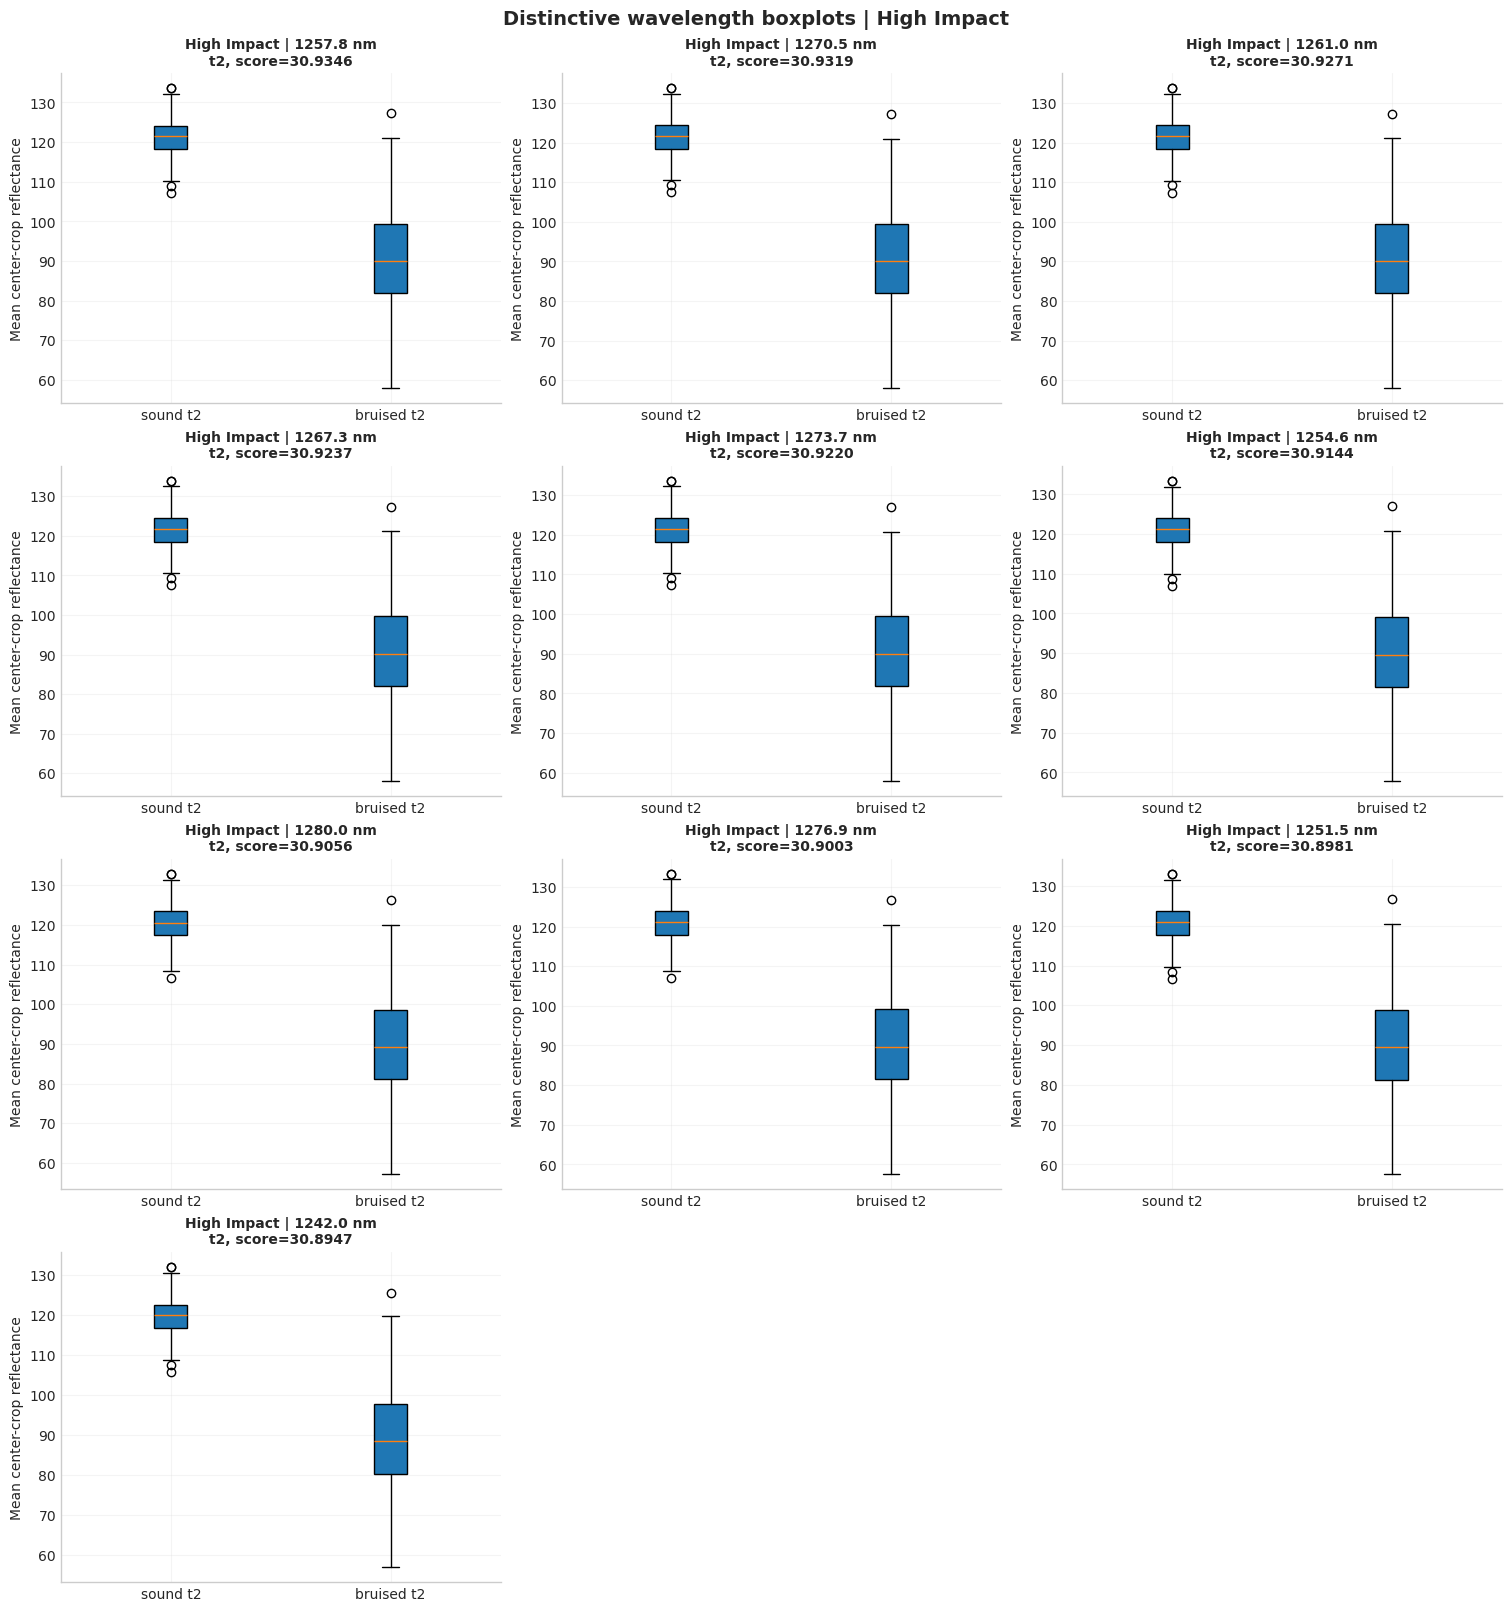

In [48]:
# Optional: boxplots for one already-computed impact group.
GROUP_FOR_BOXPLOTS = 'high_impact'

result_bundle = IMPACT_RESULTS[GROUP_FOR_BOXPLOTS]
boxplot_distinctive_bands(
    result_bundle['group_data'],
    result_bundle['topk_result'],
    GROUP_FOR_BOXPLOTS,
)
